In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pickle
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import configparser
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from torchvision.models import resnet18
import torch.nn as nn
import cv2
import torch.nn.functional as F
import torchvision.models as models

In [2]:
MiM_path = Path(os.getcwd()).parent
BASE = Path(MiM_path/'data')

In [3]:
with open(BASE/'labels/DDR.pkl','rb') as f:
    DDR = pickle.load(f)


# Voy a usar una de las imagenes que uso FU
file_path_w = DDR[DDR.filename == '007-7255-400.jpg'].file_path.item()
file_path_b = DDR[DDR.filename == '007-0199-000.jpg'].file_path.item()

# Preprocesamiento

## 1. Importar imagen con OpenCV

In [4]:
import cv2

image_w = cv2.imread(file_path_w) # OpenCV por default importa los canales e ignora el de transparencia si existiera. Los canales son BGR
image_b = cv2.imread(file_path_b)

In [6]:
image_w.shape, image_b.shape

((1632, 2464, 3), (1721, 1725, 3))

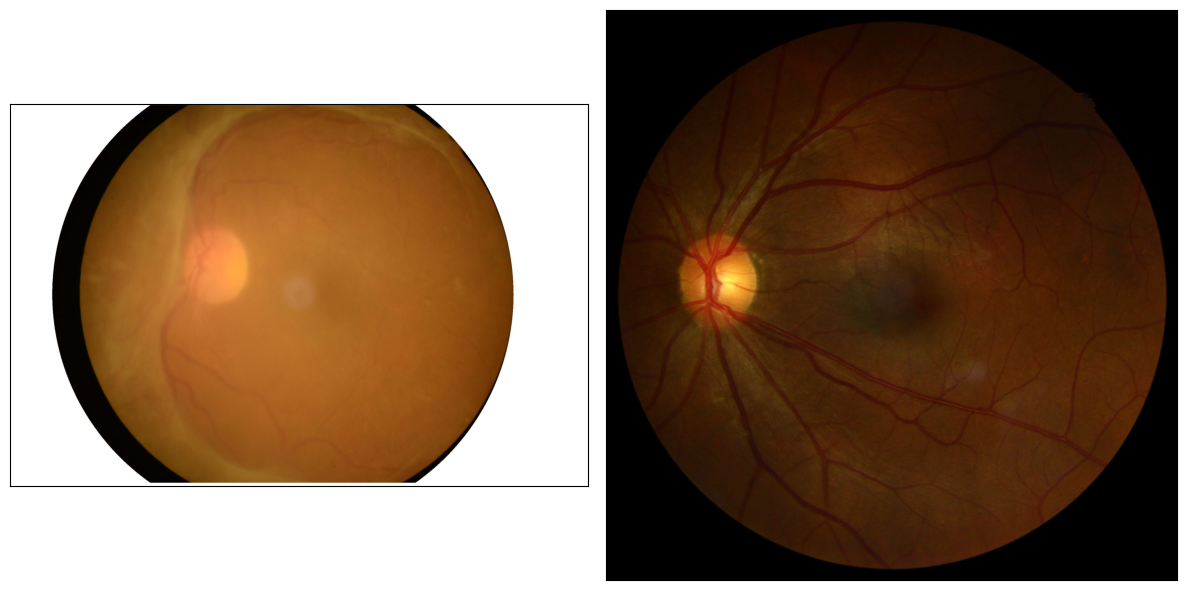

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(image_w, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image_b, cv2.COLOR_BGR2RGB))

for ax in axes:
    ax.set_xticks([])  # quitar marcas en eje x
    ax.set_yticks([])  # quitar marcas en eje y
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

plt.tight_layout()
plt.show()



## 2. Fondo blanco?

In [11]:
# Hay algunas imagenes que tienen fondo blanco que el preprocesamiento de Fu no lo soporta
# tengo que cambiar el fondo para que sea negro sino la mascara no va a funcionar

gray_w = cv2.cvtColor(image_w, cv2.COLOR_BGR2GRAY) # paso a un solo canal gris. Si el pixel es blanco entonces le queda 255 y si es negro le queda 0.
gray_b = cv2.cvtColor(image_b, cv2.COLOR_BGR2GRAY)

freq_intensity_w = np.bincount(gray_w.ravel().astype(np.int64)) # pone todos los valores en un solo array, ordena los valores y hace un conteo de frecuencia.
freq_intensity_b = np.bincount(gray_b.ravel().astype(np.int64))

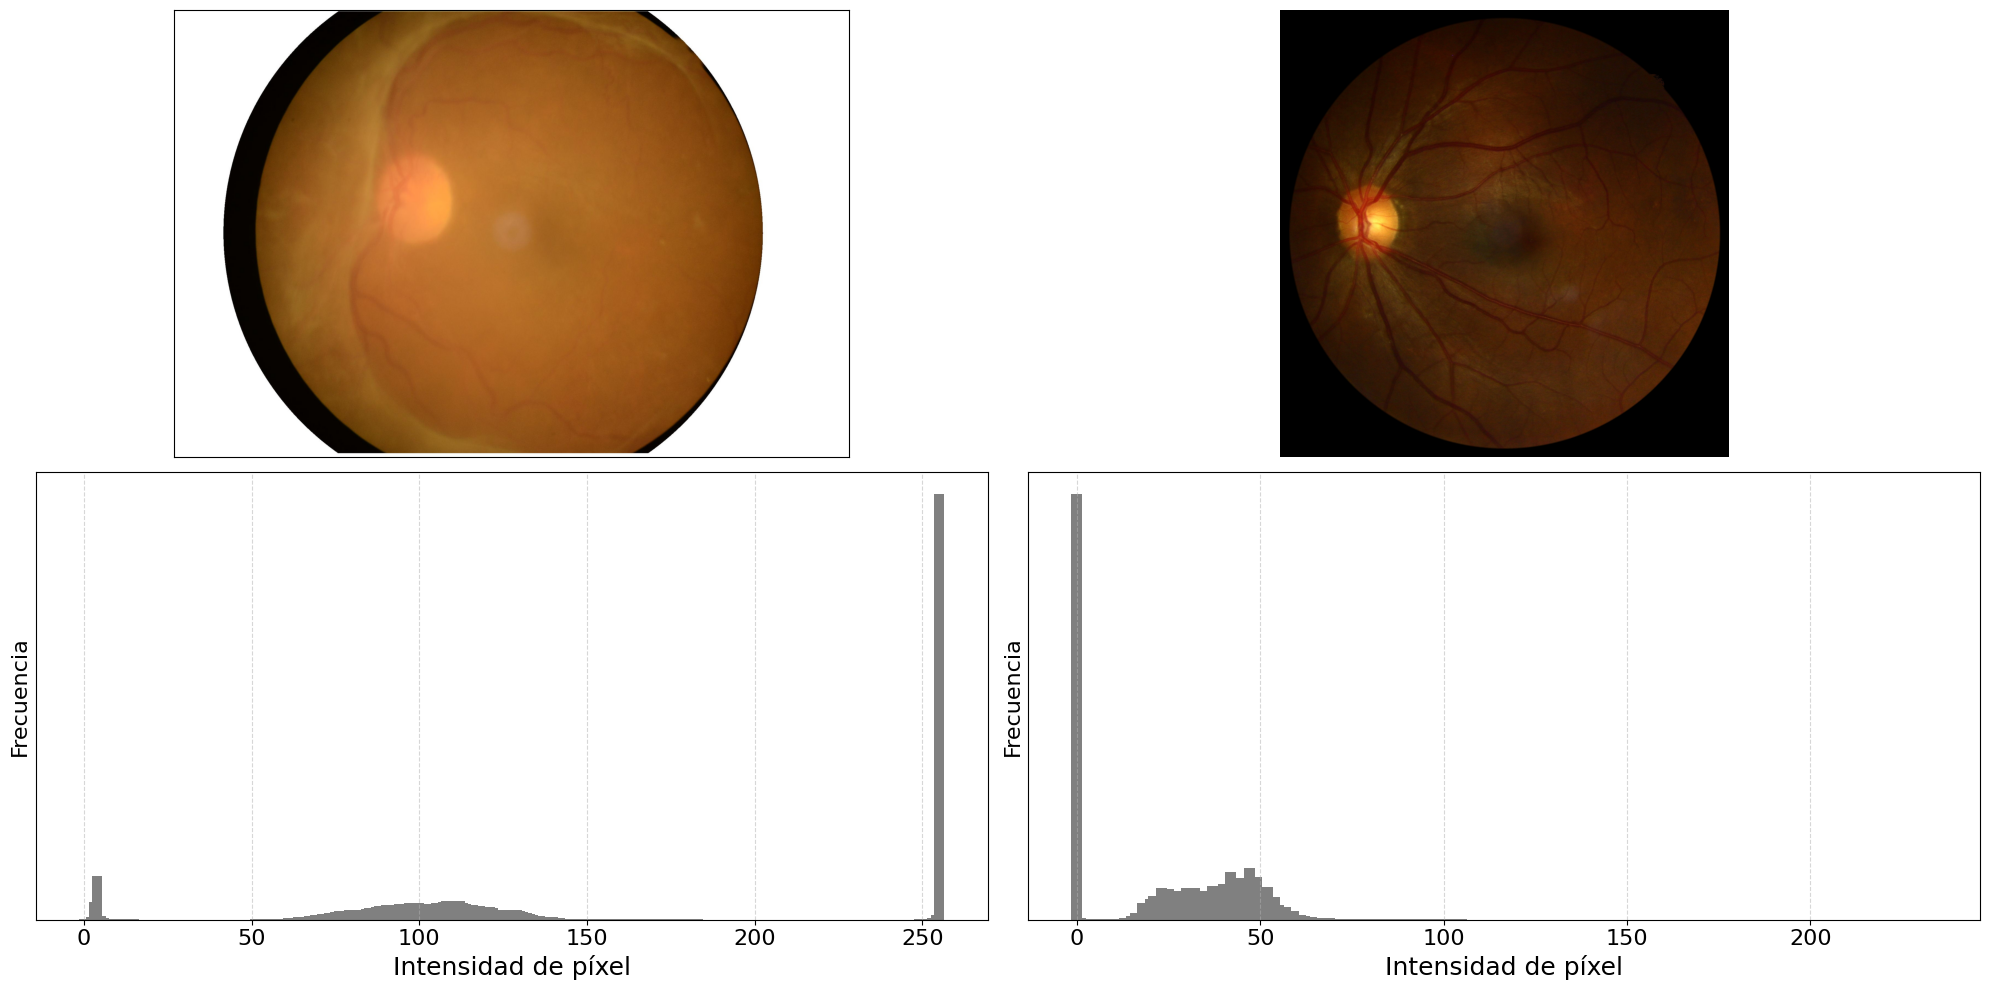

In [32]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, figsize=(20, 10))

# Imágenes
axes[0, 0].imshow(cv2.cvtColor(image_w, cv2.COLOR_BGR2RGB))
axes[0, 0].set_xticks([]) 
axes[0, 0].set_yticks([])
axes[0, 0].spines['top'].set_visible(True)
axes[0, 0].spines['right'].set_visible(True)
axes[0, 0].spines['bottom'].set_visible(True)
axes[0, 0].spines['left'].set_visible(True)

axes[0, 1].imshow(cv2.cvtColor(image_b, cv2.COLOR_BGR2RGB))
axes[0, 1].axis("off")

# Histogramas
axes[1, 0].bar(np.arange(len(freq_intensity_w)), freq_intensity_w, color='gray', width=3.0)
axes[1, 0].set_xlabel("Intensidad de píxel", fontsize=18)
axes[1, 0].set_ylabel("Frecuencia", fontsize=16)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)
axes[1, 0].ticklabel_format(style='plain', axis='y')  # Fuerza formato decimal
axes[1, 0].yaxis.get_offset_text().set_visible(False)  # Oculta 1e6 al costado del eje
axes[1, 0].set_yticks([])
axes[1, 0].tick_params(axis='x', labelsize=16)


axes[1, 1].bar(np.arange(len(freq_intensity_b)), freq_intensity_b, color='gray', width=3.0)
axes[1, 1].set_xlabel("Intensidad de píxel", fontsize=18)
axes[1, 1].set_ylabel("Frecuencia", fontsize=16)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)
axes[1, 1].set_yticks([])
axes[1, 1].tick_params(axis='x', labelsize=16)



plt.savefig("histograma_con_imagenes.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


In [34]:
# Si la moda es el 255 entonces quiere decir que el fondo es blanco
if np.where(freq_intensity_w == freq_intensity_w.max())[0].item() == 255:
    index = np.where(gray_w == 255) # donde estan ubicados los pixeles blancos
    imagen_modified = image_w.copy()
    imagen_modified[index[0],index[1],...] = 0 # reemplazo por negro
else:
    imagen_modified = image_w.copy()

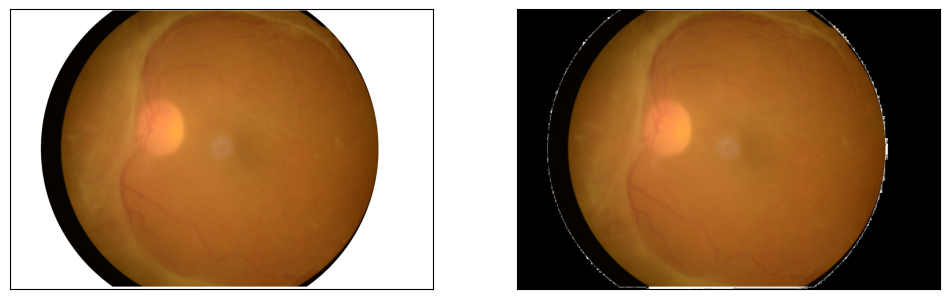

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(image_w, cv2.COLOR_BGR2RGB))
axes[0].set_yticks([])
axes[0].set_xticks([])

axes[1].imshow(cv2.cvtColor(imagen_modified, cv2.COLOR_BGR2RGB))
axes[1].set_yticks([])
axes[1].set_xticks([])

plt.savefig("fondo_blanco_a_negro.png", dpi=300, bbox_inches='tight')

plt.show()

## 3. FOV mask

### 3.2 Detectar un circulo si fuera posible

Se aplica el desenfoque para bajar el ruido de la imagen y preservar la estructura principal.

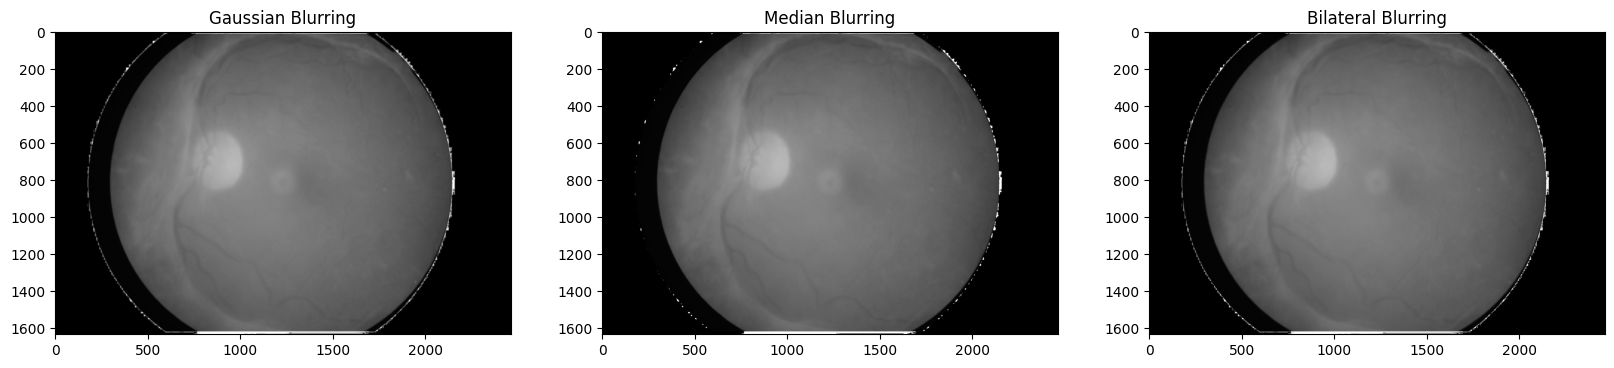

In [44]:
gray = cv2.cvtColor(imagen_modified, cv2.COLOR_BGR2GRAY)

Gaussian = cv2.GaussianBlur(gray, (7, 7), 0) 
gray_blur = cv2.medianBlur(gray, 7)

# Median Blur: The Median Filter is a non-linear digital filtering technique, often used to remove noise from an image or signal. 
# Median filtering is very widely used in digital image processing because, under certain conditions, it preserves edges while removing noise.
# It is one of the best algorithms to remove Salt and pepper noise.

bilateral = cv2.bilateralFilter(gray, 9, 75, 75) 


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(Gaussian, cmap="gray")
axes[0].set_title("Gaussian Blurring")

axes[1].imshow(gray_blur, cmap="gray")
axes[1].set_title("Median Blurring")

axes[2].imshow(bilateral, cmap="gray")
axes[2].set_title("Bilateral Blurring")

plt.show()

In [47]:
# Buscamos si hay un circulo en la imagen
# https://docs.opencv.org/4.x/dd/d1a/group__imgproc__feature.html#ga47849c3be0d0406ad3ca45db65a25d2d
rows = gray_blur.shape[0]
cols = gray_blur.shape[1]
circles = cv2.HoughCircles(gray_blur,
                           method=cv2.HOUGH_GRADIENT,
                           dp=1,
                           minDist=cols//2, # minima distancia entre los distintos circulos. Yo quiero un solo circulo asique pongo aca un valor alto
                           param1=60, # Umbral superior de Canny (bordes). Si pongo 100, OpenCV usa como umbral inferior la mitad. Valores bajos: Detecta más bordes (más ruido). Valores altos: Solo bordes fuertes.
                           param2=30, # Umbral del acumulador de Hough. Bajo: Detecta más círculos (más falsos positivos). Alto: Solo círculos bien definidos.
                           minRadius=min(rows,cols)//4, # yo quiero detectar solo un circulo, el mejor y mas grande posible. La mayor parte de la imagen deberia ser la rutina. No creo que ninguna imagen de fondo de ojo ocupe un cuarto del total.
                           maxRadius=max(rows,cols)//2)

circles = np.uint16(np.around(circles)) # circles es dtype=float32 lo paso a int

if circles is not None and circles.shape[1] == 1:
    circle = circles[0,0]
    mask_black = np.zeros((gray_blur.shape[0],gray_blur.shape[1]),np.uint16) # creo una imagen negra donde insertar la mascara del circulo
    center = (circle[0], circle[1])
    radius = circle[2]
    image_with_circle = cv2.cvtColor(gray_blur, cv2.COLOR_GRAY2RGB)
    cv2.circle(image_with_circle, center, radius, (255, 0, 0), 3) 
    cv2.circle(mask_black, center, radius, 255 , -1)

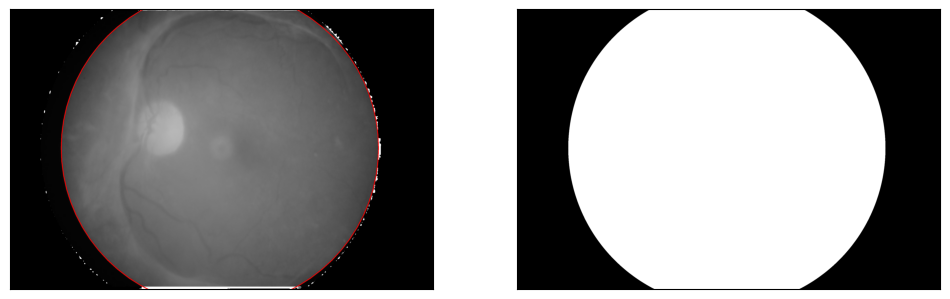

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image_with_circle)
axes[0].set_yticks([])
axes[0].set_xticks([])

axes[1].imshow(mask_black, cmap="gray")
axes[1].set_yticks([])
axes[1].set_xticks([])

plt.savefig("circulos_hough.png", dpi=300, bbox_inches='tight')

plt.show()

#### 3.2.1 Aplicar FOV mask

In [51]:
img_preproc = image_w.copy()
img_preproc[mask_black<=0,...]=0 # todos los pixeles que en la mascara son negros los pone negro tambien en la imagen asi me quedo solo con el circulo

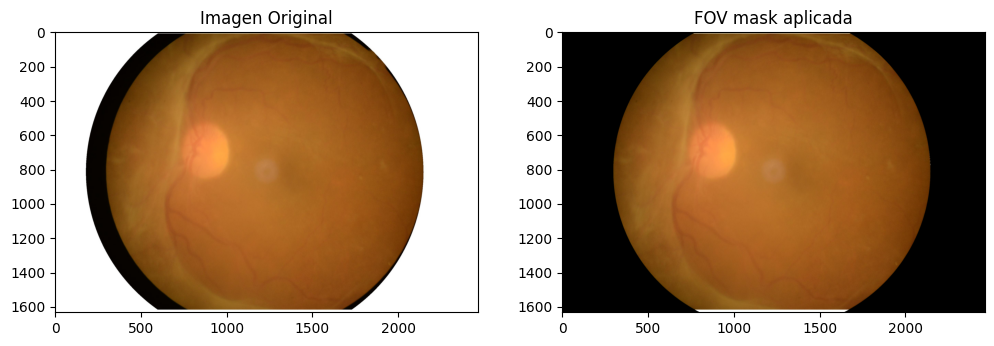

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(image_w, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen Original")

axes[1].imshow(cv2.cvtColor(img_preproc, cv2.COLOR_BGR2RGB))
axes[1].set_title("FOV mask aplicada")

plt.show()

#### 3.2.2 Bounding Box

In [57]:
from skimage import measure

# regionprops devuelve caracteristicas de las categorias en una imagen binaria.
regions = measure.regionprops(np.asarray(mask_black, dtype=np.uint8))

for i, region in enumerate(regions):
    print(f"Región {i + 1}:")
    print(f" - Área: {region.area}")
    print(f" - Centroide: {region.centroid}")
    print(f" - Perímetro: {region.perimeter}")
    print(f" - Bounding Box: {region.bbox}")
    print(f" - Orientación: {region.orientation}")
    print()

Región 1:
 - Área: 66258.0
 - Centroide: (np.float64(122.27142382806605), np.float64(156.0))
 - Perímetro: 964.9259735953042
 - Bounding Box: (0, 2, 244, 311)
 - Orientación: 1.5707963267948966



#### 3.2.3 Recortar

In [58]:
coordinates = regions[0].bbox

img_preproc = img_preproc[coordinates[0]:coordinates[2],coordinates[1]:coordinates[3]]

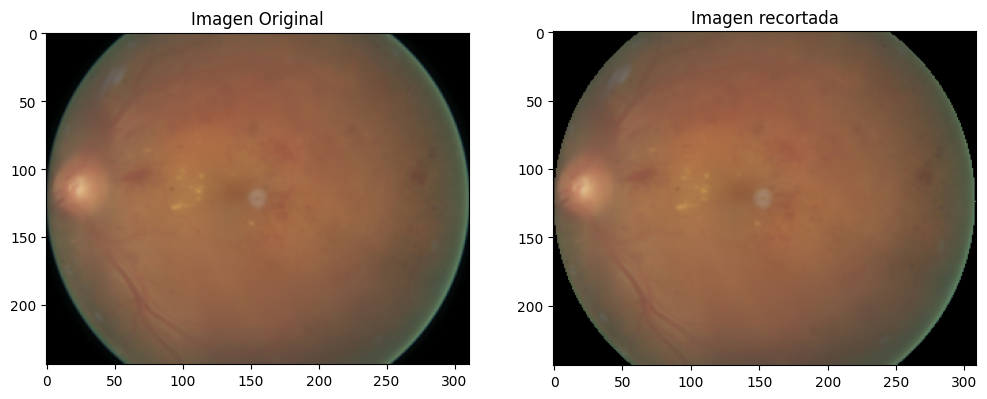

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen Original")

axes[1].imshow(cv2.cvtColor(img_preproc, cv2.COLOR_BGR2RGB))
axes[1].set_title("Imagen recortada")

plt.show()

#### 3.2.4 Resize a 512x512

In [60]:
img_preproc = cv2.resize(img_preproc, (512, 512))

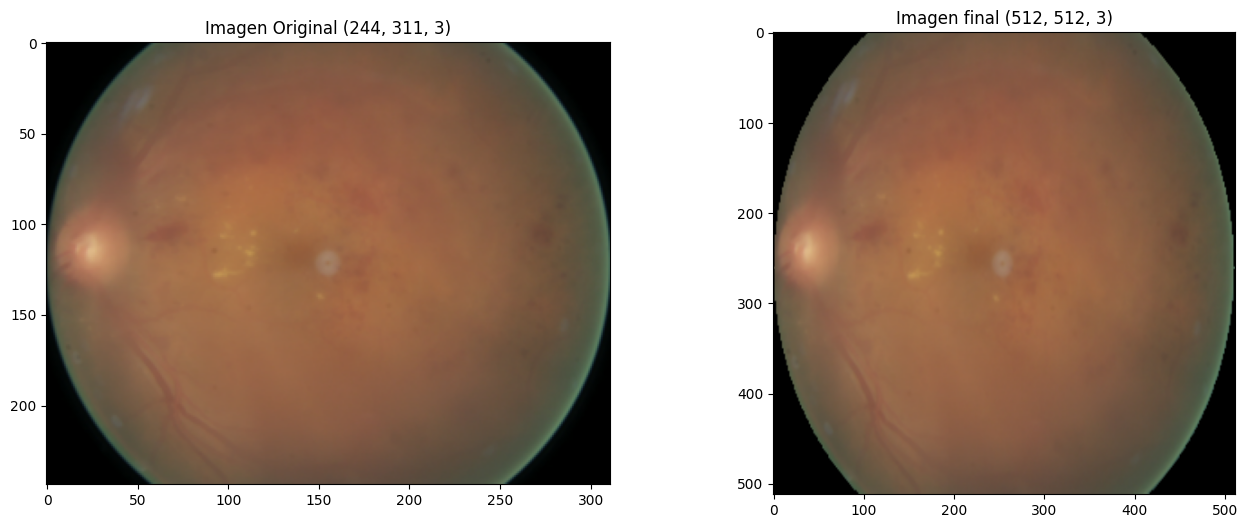

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Imagen Original {image.shape}")

axes[1].imshow(cv2.cvtColor(img_preproc, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Imagen final {img_preproc.shape}")

plt.show()

### 3.3 Si no es posible detectar un circulo

#### 3.3.1 Suma de intensidades

In [53]:
# Las fotos de fondo de ojo son imágenes a color, por lo que tienen 3 canales (R, G, B). 
# El FOV o field of view es la región de la imagen en la que hay contenido de la retina.
# Todo lo que no es FOV toma intensidades negras (es decir, muy cercanas a 0). Sin embargo,
# hay algunas cámaras de fondo de ojo en las que el negro no es tan negro, si no que las 
# intensidades tienen algo de ruido (entonces por ahí llegan al 10 o al 20, pero siempre valores bajos).
# Sumar los canales R, G, B te permite sumar las contribuciones de intensidades de los 3 canales.
# El resultado sería una imagen en la que las diferencias entre la zona con contenido de la retina y
# la que está fuera del FOV son más notorias.

## Suma los 3 canales (axis=2). También puedo pasarle el objeto de PIL "im".
sum_of_channels = np.sum(imagen_modified,axis=2) # OJO aca si pongo dtype=np.uint8 que va de 0 a 255 cuando la suma supera 255 pone 256 = 0, 257 = 1, etc.
sum_of_channels_uint8 = np.sum(imagen_modified,axis=2,dtype=np.uint8)

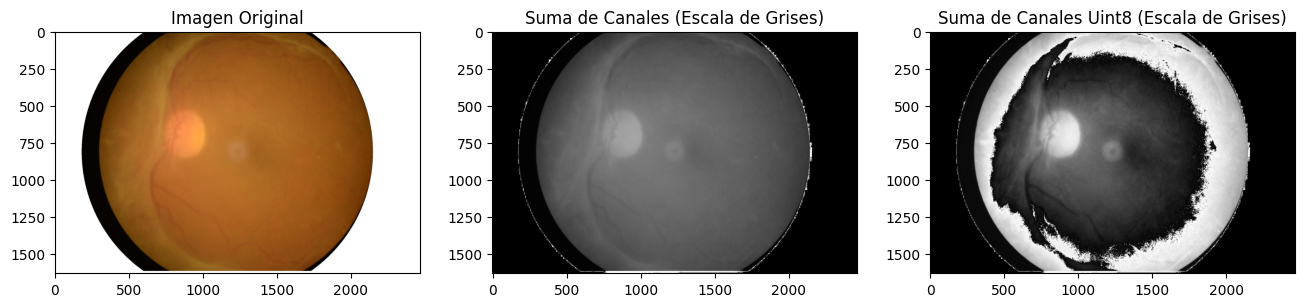

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(image_w, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen Original")

axes[1].imshow(sum_of_channels, cmap="gray")
axes[1].set_title("Suma de Canales (Escala de Grises)")

axes[2].imshow(sum_of_channels_uint8, cmap="gray")
axes[2].set_title("Suma de Canales Uint8 (Escala de Grises)")


plt.show()

#### 3.3.2 Umbral OTSU

umbral del fondo: 143


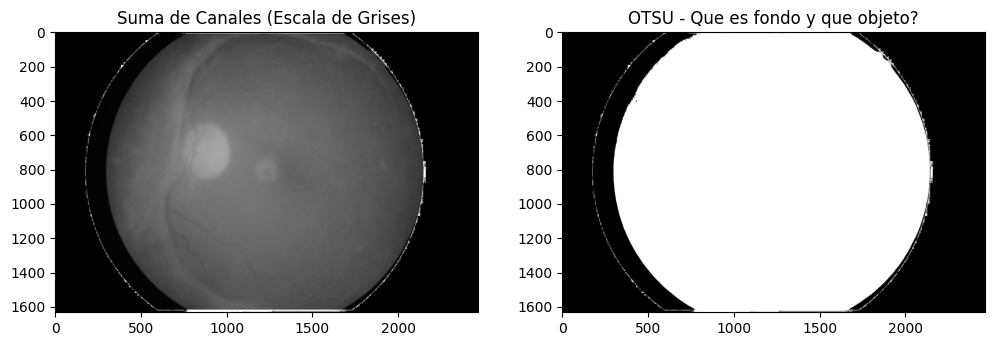

In [61]:
# El método Otsu analiza el histograma de la imagen para encontrar un valor de umbral que minimice la varianza intraclase 
# y maximice la varianza interclase, separando así de forma óptima los píxeles en dos grupos: uno que representa los objetos 
# y otro el fondo.

from skimage import filters

threshold_fondo = filters.threshold_otsu(sum_of_channels.astype(np.int64)) # lo paso a int64 porque el skimage no espera recibir tipos de datos uint64 que son solo positivos
print(f'umbral del fondo: {threshold_fondo}')

fov_mask = sum_of_channels > threshold_fondo

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(sum_of_channels, cmap="gray")
axes[0].set_title("Suma de Canales (Escala de Grises)")

axes[1].imshow(fov_mask, cmap="gray")
axes[1].set_title("OTSU - Que es fondo y que objeto?")

plt.show()

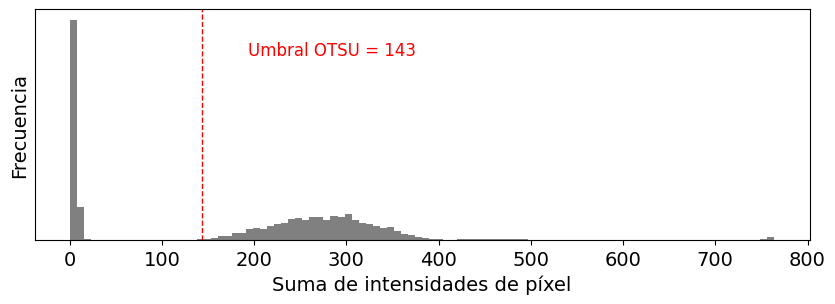

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.hist(sum_of_channels.ravel(), bins=100, color="gray") # sum_of_channels tiene dos dimension, con ravel lo achata a una dimension.
ax.set_xlabel("Valor de Intensidad")
ax.set_ylabel("Frecuencia")

ax.set_xlabel("Suma de intensidades de píxel", fontsize=14)
ax.set_ylabel("Frecuencia", fontsize=14)
# axes[1, 1].grid(True, linestyle='--', alpha=0.5)
ax.set_yticks([])
ax.tick_params(axis='x', labelsize=14)

ax.axvline(threshold_fondo, color='red', linestyle='--', linewidth=1)
ax.text(threshold_fondo + 50, ax.get_ylim()[1]*0.8, f"Umbral OTSU = {threshold_fondo}", color='red', fontsize=12)


plt.savefig("histograma_suma.png", dpi=300, bbox_inches='tight')


plt.show()

# En el plot se ve que es una bimodal, un grupo reducido cerca del 0 que son en su mayoria el borde negro de la imagen y los otros
# alrededor del 300 que son los pixel que forman parte del ojo.

#### 3.3.3 Rellenar agujeros

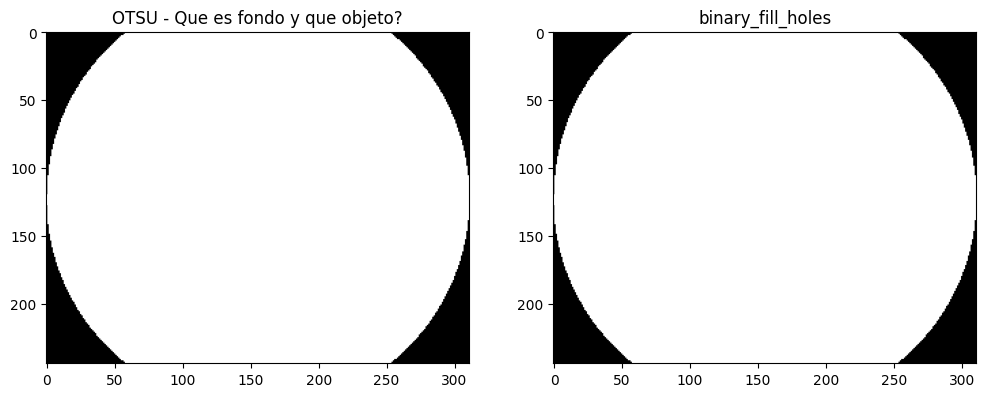

In [81]:
from scipy.ndimage import binary_fill_holes

bi = binary_fill_holes(fov_mask)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(fov_mask, cmap="gray")
axes[0].set_title("OTSU - Que es fondo y que objeto?")

axes[1].imshow(bi, cmap="gray")
axes[1].set_title("binary_fill_holes")

plt.show()

#### 3.3.4 Aplicar FOV mask

In [93]:
img_preproc = image.copy()
img_preproc[np.asarray(bi, dtype=np.uint8)<=0,...]=0 

#### 3.3.5 Bounding Box

In [94]:
from skimage import measure

# regionprops devuelve caracteristicas de las categorias en una imagen binaria.
regions = measure.regionprops(np.asarray(bi, dtype=np.uint8))

for i, region in enumerate(regions):
    print(f"Región {i + 1}:")
    print(f" - Área: {region.area}")
    print(f" - Centroide: {region.centroid}")
    print(f" - Perímetro: {region.perimeter}")
    print(f" - Bounding Box: {region.bbox}")
    print(f" - Orientación: {region.orientation}")
    print()

Región 1:
 - Área: 67201.0
 - Centroide: (np.float64(121.68128450469487), np.float64(155.34938468177558))
 - Perímetro: 972.4406922210657
 - Bounding Box: (0, 0, 244, 311)
 - Orientación: 1.5701852835190846



#### 3.3.6 Recortar

In [95]:
coordinates = regions[0].bbox

img_preproc = img_preproc[coordinates[0]:coordinates[2],coordinates[1]:coordinates[3]]

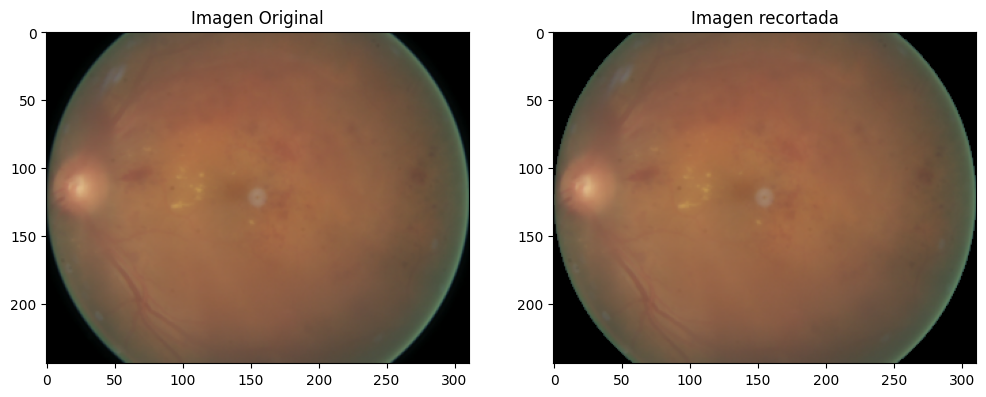

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen Original")

axes[1].imshow(cv2.cvtColor(img_preproc, cv2.COLOR_BGR2RGB))
axes[1].set_title("Imagen recortada")

plt.show()

#### 3.3.7 Resize a 512x512

In [97]:
img_preproc = cv2.resize(img_preproc, (512, 512))

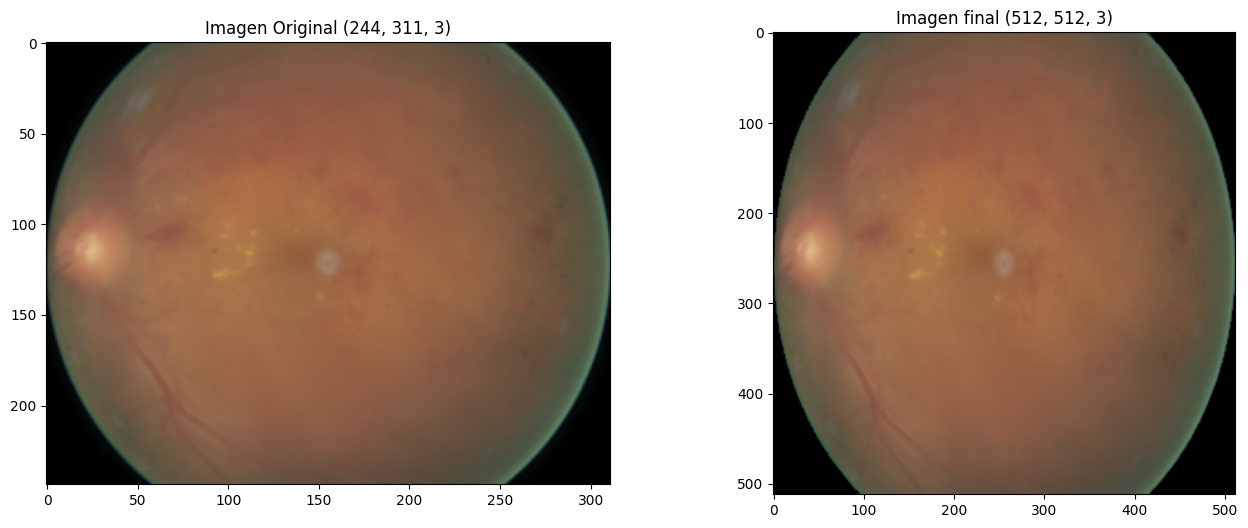

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Imagen Original {image.shape}")

axes[1].imshow(cv2.cvtColor(img_preproc, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Imagen final {img_preproc.shape}")

plt.show()

# Metricas de los modelos

## Evaluate model

In [4]:
class EyeDataset(Dataset):
  
  def __init__(self, data_path, partition, mean, std, transformations=None):
    '''
    - data_path: ruta base donde están las imágenes y configuraciones
    - partition: 'training', 'validation' o 'test'
    - mean: media para normalizar los datos
    - std: desvío estándar
    - transformations: la lista de transformaciones a aplicar al dataset de train
    '''

    # chequeo que no entre cualquier cosa en vez de partition
    assert partition in ['training', 'validation', 'test'], 'partition has to be training, validation or test, not {}'.format(partition)

    # transformaciones
    data_transforms = [transforms.ToTensor(),
                       transforms.Normalize(mean=mean, std=std)]
    
    if (partition == 'training') and not (transformations is None):
      data_transforms = transformations + data_transforms
      
    self.data_transforms = transforms.Compose(data_transforms)
    
    self.data_path = Path(data_path)

    # listado de imagenes para cada dataset
    data_config = configparser.ConfigParser()
    data_config.read(self.data_path/'data/splits/global_binaria.ini')

    # listado de labels para cada imagen
    labels_config = configparser.ConfigParser()
    labels_config.read(self.data_path/'data/labels/global_labels.ini')

    self.data = [(image, int(labels_config['label'].get(image)))
                  for image in data_config['split'].get(partition).split(sep=',')
                  ]
    
    # hacemos una lista de nombres para las clases
    self.class_names = ['buena', 'mala']


  def __len__(self):
    '''
    Método que devuelve la cantidad de elementos del dataset
    '''
    return len(self.data)
  
  def __getitem__(self, index):
    '''
    Método que devuelve el elemento index del dataset
    '''
    # obtengo la ruta de la imagen y su etiqueta asociada
    img_path, label = self.data[index]

    # cargo la imagen
    img = Image.open(self.data_path/'data/images'/(img_path+'.png')).convert("RGB") # uso PIL porque es compatible con transforms. Importa la imagen en el formato que espera pytorch 
                                                                                    # y aclaro RGB porque PIL importa en el formato original y puede no ser RGB qu es lo que espera pytorch
    # transformaciones
    img = self.data_transforms(img)

    # convierto la etiqueta en un tensor de tipo long
    label = torch.tensor(label, dtype=torch.long)

    # retornamos el par
    return (img, label)

In [5]:
mean=torch.tensor([0.1948, 0.2880, 0.4238])
std=torch.tensor([0.1661, 0.2021, 0.2782])

validation_set = EyeDataset(data_path=Path(os.getcwd()).parent,
                            partition='validation',
                            mean=mean,
                            std=std)

In [6]:
mean=torch.tensor([0.1948, 0.2880, 0.4238])
std=torch.tensor([0.1661, 0.2021, 0.2782])

test_set = EyeDataset(data_path=Path(os.getcwd()).parent,
                            partition='test',
                            mean=mean,
                            std=std)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5233644..3.2186139].


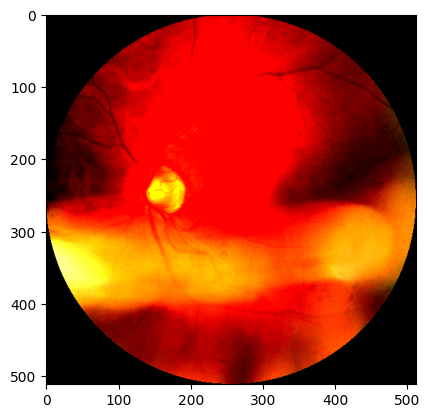

In [ ]:
# importo el primer elemento del dataset de entrenamiento y lo imprimo
# Ya no es la imagen original porque la clase EyeDataset le aplica las transformaciones y normaliza
img,label = validation_set[0]

plt.imshow(img.permute(1,2,0))

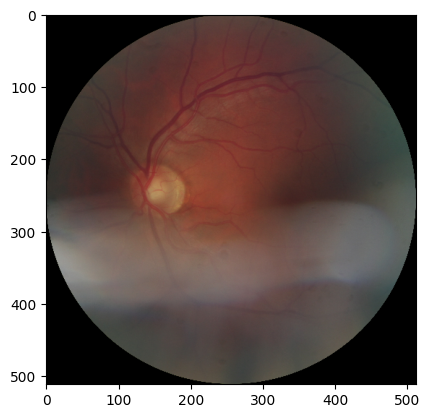

In [21]:
# De-normalizo la imagen para mostrarla
img,label = validation_set[0]

plt.imshow(img.permute(1,2,0)* std + mean)

### Prediccion

In [7]:
model = resnet18(pretrained=True)
# nro de features de salida porque la ResNet se entreno para el dataset ImageNet que tiene 1000 clases.
num_ftrs = model.fc.in_features
# creo la capa de clasificacion para la clasificaion binaria de imagenes de la retina
model.fc = nn.Linear(num_ftrs, 2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model_path = "best_baseline_layer4_fc_adam_Plateau.pth"
model.load_state_dict(torch.load(model_path,map_location=device))
model.eval()

c:\Users\gabim\anaconda3\envs\mim_entorno\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\gabim\anaconda3\envs\mim_entorno\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\gabim\AppData\Local\Temp\ipykernel_16644\3758572353.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.c

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [117]:
# Crear diccionario para guardar activaciones
activations = {}

# Definir hooks para capturar activaciones
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Registrar hooks en cada bloque
model.conv1.register_forward_hook(get_activation('conv1'))
model.layer1.register_forward_hook(get_activation('layer1'))
model.layer2.register_forward_hook(get_activation('layer2'))
model.layer3.register_forward_hook(get_activation('layer3'))
model.layer4.register_forward_hook(get_activation('layer4'))

In [118]:
img,label = validation_set[3]
img = img.unsqueeze(0).to(device) 
label = label.to(device)

with torch.no_grad():
        output = model(img)
        pred = torch.argmax(output, dim=1).item()
        
print("label:", label)
print("Predicción:", pred)

label: tensor(0, device='cuda:0')
Predicción: 0


### Activaciones

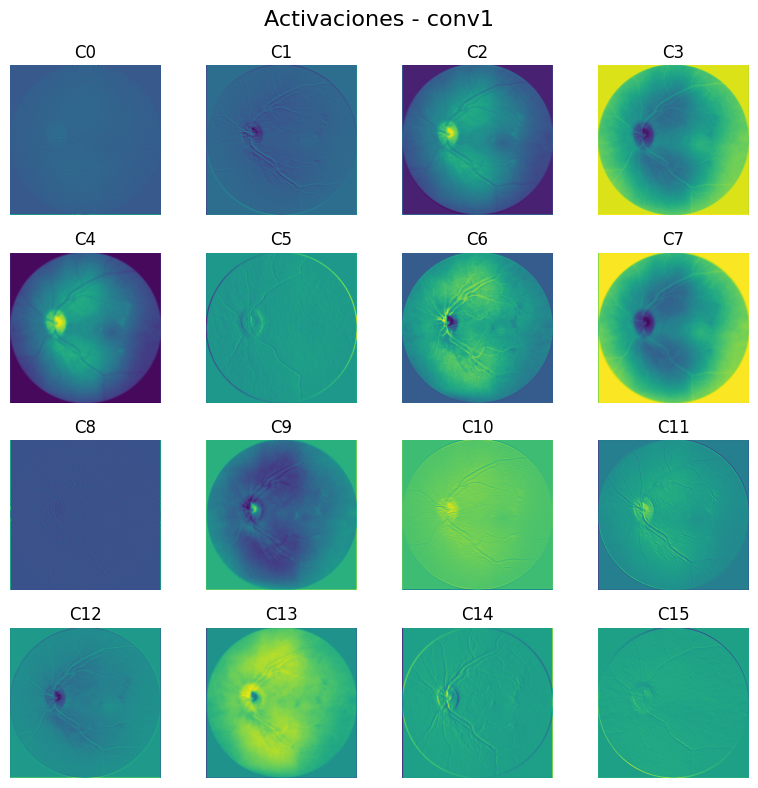

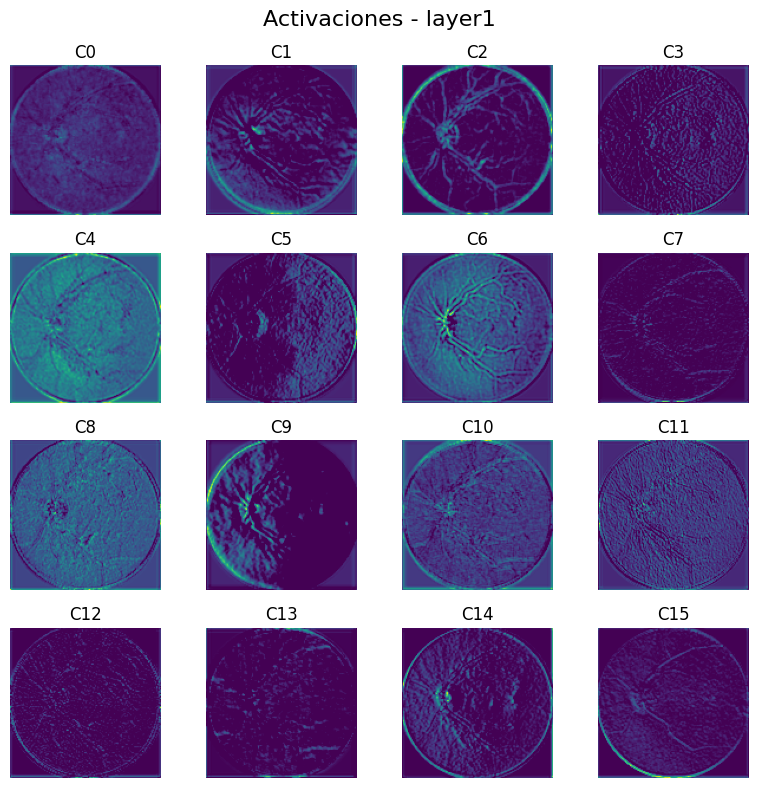

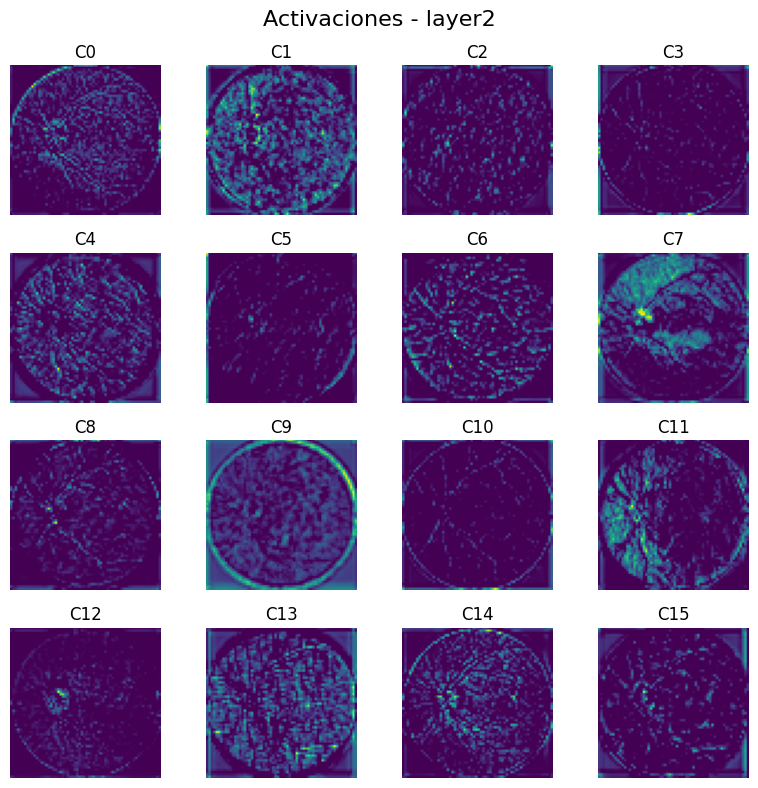

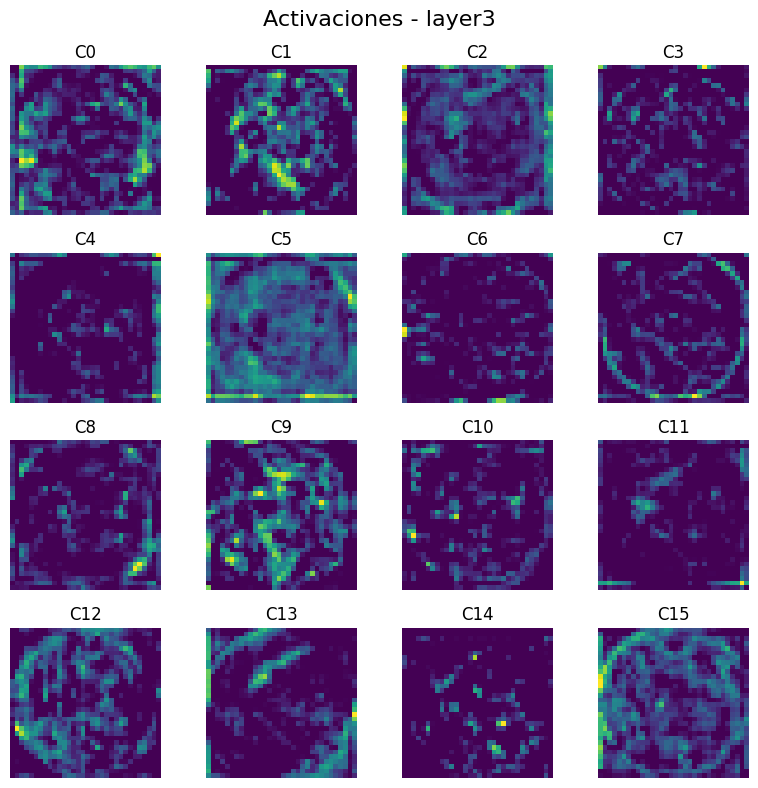

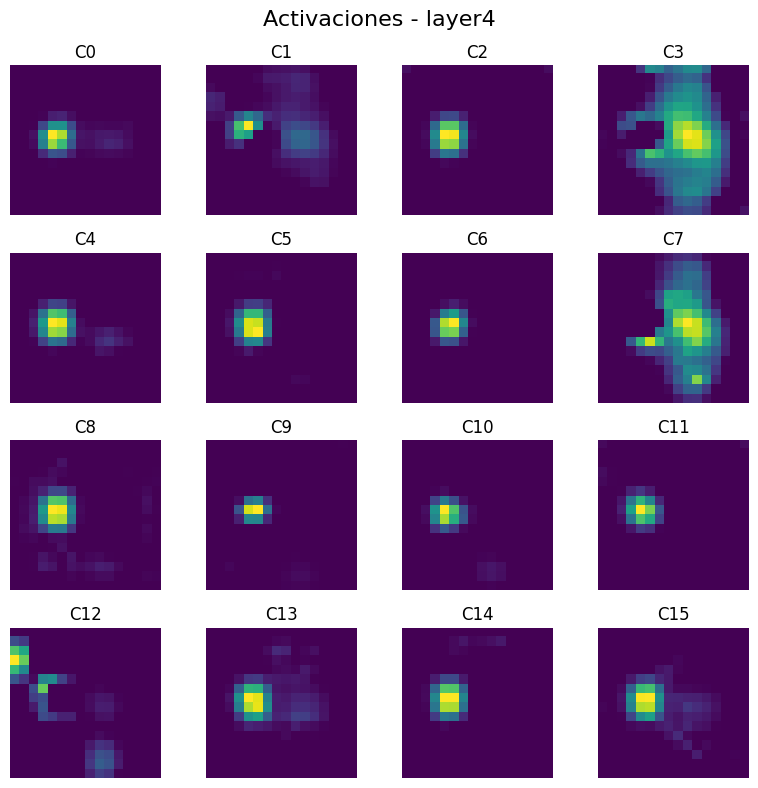

In [121]:
def plot_activations(activation, title='', max_channels=16):
    num_channels = activation.shape[1]
    n = min(num_channels, max_channels)
    cols = 4
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * 2, rows * 2))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(activation[0, i].cpu(), cmap='viridis')
        plt.axis('off')
        plt.title(f'C{i}')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualizar cada bloque
for layer_name in ['conv1', 'layer1', 'layer2', 'layer3', 'layer4']:
    plot_activations(activations[layer_name], title=f'Activaciones - {layer_name}')


### Filtros

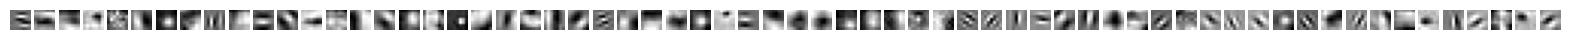

In [55]:
def plot_filters(model):
    filters = model.conv1.weight.data
    fig, axes = plt.subplots(1, filters.size(0), figsize=(20, 20))
    for i in range(filters.size(0)):
        ax = axes[i]
        ax.imshow(filters[i, 0].cpu(), cmap='gray')
        ax.axis('off')
    plt.show()

plot_filters(model)


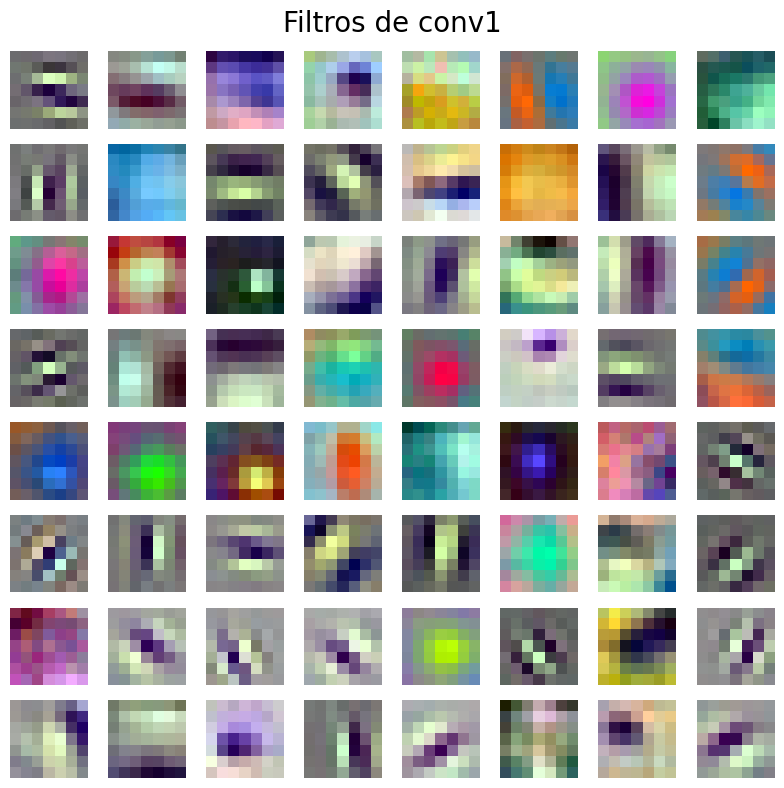

In [65]:
import matplotlib.pyplot as plt

def plot_filters_grid(model, layer_name='conv1', max_filters=64, size=2.5):
    # Obtener los filtros de la capa
    layer = getattr(model, layer_name)
    filters = layer.weight.data.cpu()
    
    n_filters = min(filters.size(0), max_filters)
    cols = 8
    rows = (n_filters + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * size, rows * size))
    axes = axes.flatten()

    for i in range(n_filters):
        filt = filters[i]

        # Si tiene 3 canales (como conv1), convertir a imagen RGB
        if filt.shape[0] == 3:
            img = filt.permute(1, 2, 0)  # [C, H, W] → [H, W, C]
            img = (img - img.min()) / (img.max() - img.min())
        else:
            img = filt[0]  # Solo primer canal si no es RGB

        axes[i].imshow(img.numpy(), cmap='gray' if filt.shape[0] != 3 else None)
        axes[i].axis('off')

    # Si hay ejes sin usar, ocultarlos
    for j in range(n_filters, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Filtros de {layer_name}', fontsize=20)
    plt.tight_layout()
    plt.show()

# Usalo así:
plot_filters_grid(model, layer_name='conv1', size=1)


Mostrando filtros de: conv1


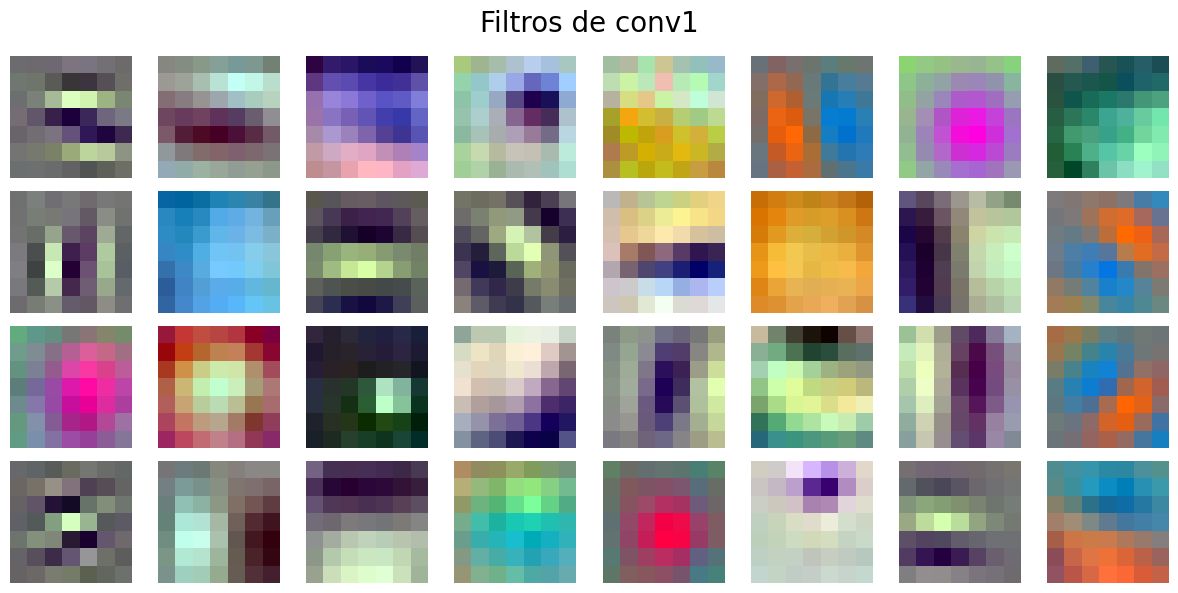

Mostrando filtros de: layer1.conv1


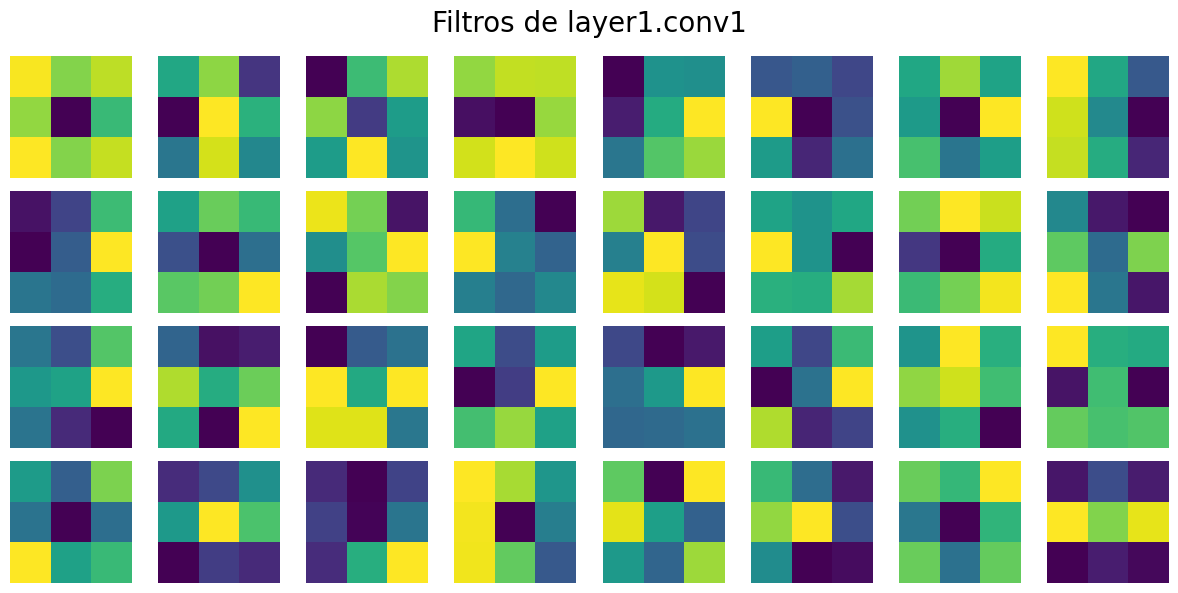

Mostrando filtros de: layer2.conv1


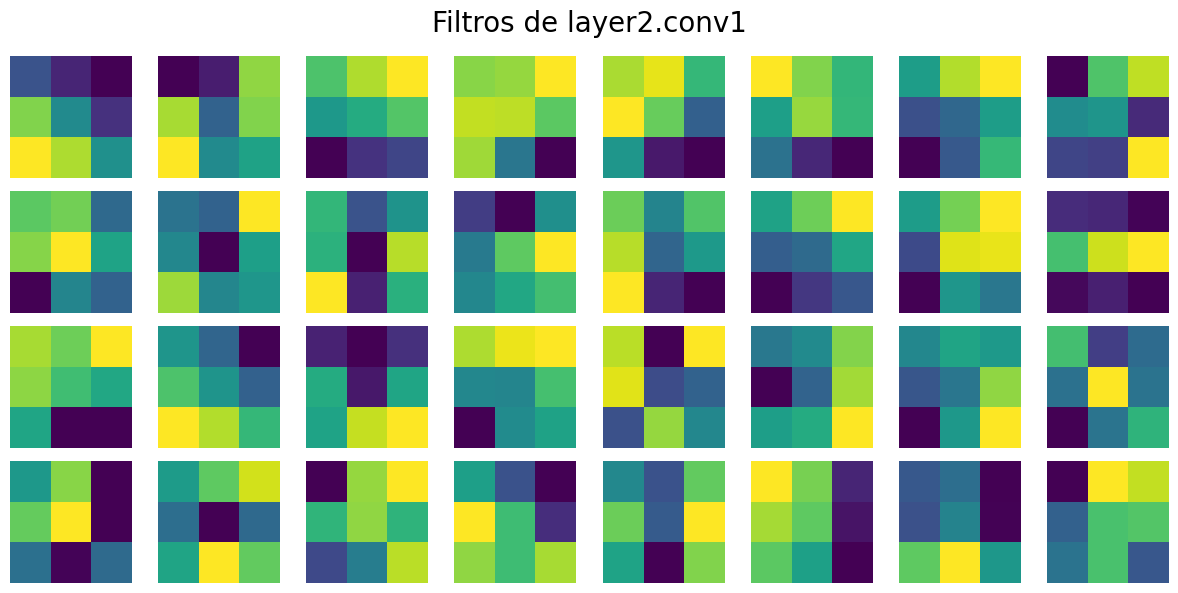

Mostrando filtros de: layer3.conv1


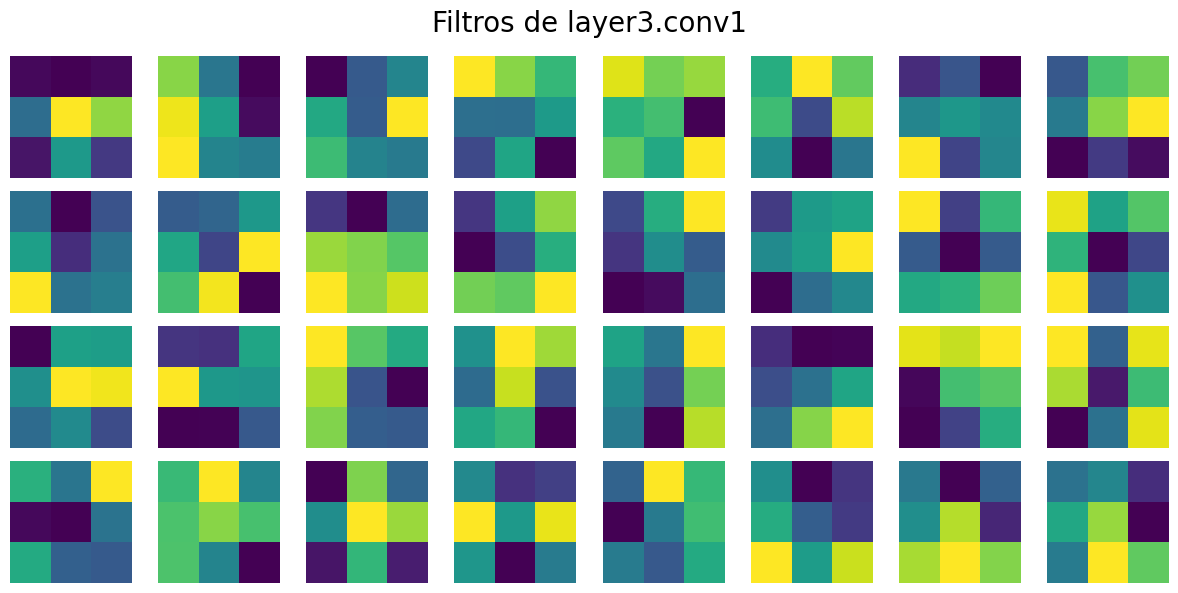

Mostrando filtros de: layer4.conv1


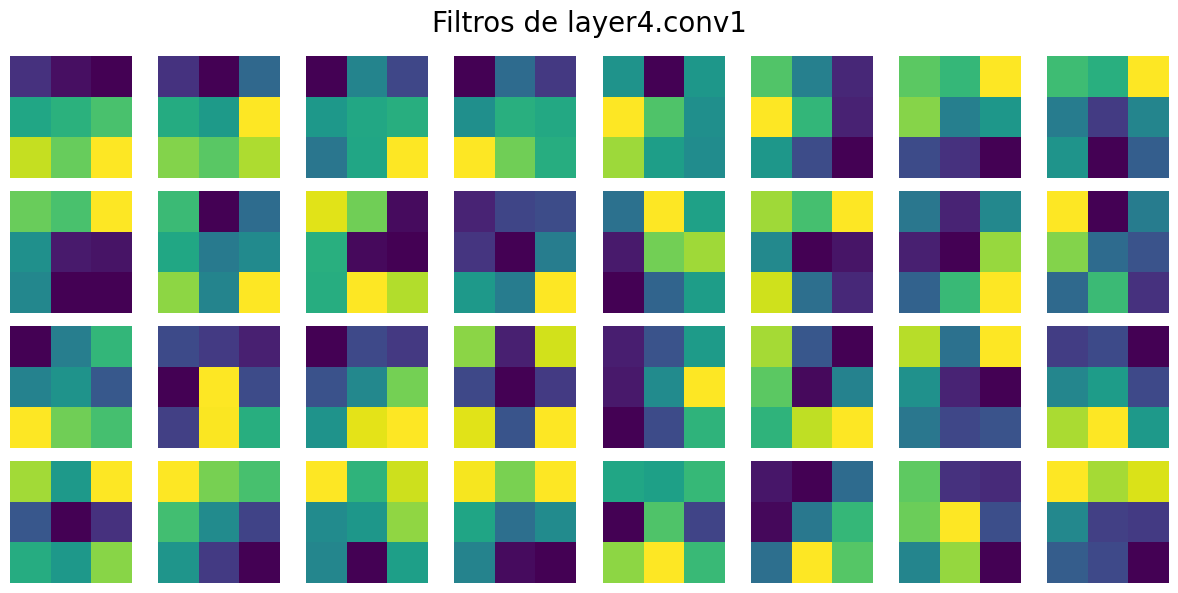

In [63]:
def plot_filters(weights, title='', channels=3, max_filters=32, size=3):
    """
    weights: tensor de pesos [out_channels, in_channels, H, W]
    channels: cantidad de canales de entrada a visualizar (3 para RGB)
    """
    weights = weights.cpu().detach()
    n_filters = min(weights.shape[0], max_filters)
    cols = 8
    rows = (n_filters + cols - 1) // cols
    plt.figure(figsize=(cols * size, rows * size))
    
    for i in range(n_filters):
        filt = weights[i]
        
        # Si tiene 3 canales (RGB), mostrar como imagen color
        if filt.shape[0] == 3:
            filt_img = filt.permute(1, 2, 0)
            filt_img = (filt_img - filt_img.min()) / (filt_img.max() - filt_img.min())
        else:
            filt_img = filt[0]
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(filt_img.detach().numpy(), cmap='viridis')
        plt.axis('off')
    
    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

# Diccionario de capas clave para visualizar
capas = {
    'conv1': model.conv1,
    'layer1.conv1': model.layer1[0].conv1,
    'layer2.conv1': model.layer2[0].conv1,
    'layer3.conv1': model.layer3[0].conv1,
    'layer4.conv1': model.layer4[0].conv1
}

# Recorrer y visualizar
for nombre, capa in capas.items():
    print(f'Mostrando filtros de: {nombre}')
    plot_filters(capa.weight, title=f'Filtros de {nombre}', size=1.5)

### Prediccion sobre conjunto de Test

In [125]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

mean=torch.tensor([0.1948, 0.2880, 0.4238])
std=torch.tensor([0.1661, 0.2021, 0.2782])

test_set = EyeDataset(data_path=Path(os.getcwd()).parent,
                      partition='test',
                      mean=mean,
                      std=std)

test_loader = DataLoader(test_set, batch_size=128, num_workers=0, pin_memory=True, shuffle=False)

In [126]:
model = resnet18(pretrained=True)
# nro de features de salida porque la ResNet se entreno para el dataset ImageNet que tiene 1000 clases.
num_ftrs = model.fc.in_features
# creo la capa de clasificacion para la clasificaion binaria de imagenes de la retina
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

model_path = "best_baseline_layer4_fc_adam_Plateau.pth"
model.load_state_dict(torch.load(model_path,map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convertir a arrays de numpy
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Mostrar clasificación
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# Mostrar matriz de confusión
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))


c:\Users\gabim\anaconda3\envs\mim_entorno\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\gabim\anaconda3\envs\mim_entorno\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\gabim\AppData\Local\Temp\ipykernel_18648\4099568172.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.co

Classification Report:
              precision    recall  f1-score   support

           0     0.9775    0.9918    0.9846     46317
           1     0.7252    0.4884    0.5837      2064

    accuracy                         0.9703     48381
   macro avg     0.8514    0.7401    0.7841     48381
weighted avg     0.9668    0.9703    0.9675     48381

Confusion Matrix:
[[45935   382]
 [ 1056  1008]]


### Grad-CAM

In [8]:
model = resnet18(pretrained=True)
# nro de features de salida porque la ResNet se entreno para el dataset ImageNet que tiene 1000 clases.
num_ftrs = model.fc.in_features
# creo la capa de clasificacion para la clasificaion binaria de imagenes de la retina
model.fc = nn.Linear(num_ftrs, 2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model_path = "best_baseline_layer4_fc_adam_Plateau.pth"
model.load_state_dict(torch.load(model_path,map_location=device))
model.eval()

C:\Users\gabim\AppData\Local\Temp\ipykernel_16644\3758572353.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path,map_location=de

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
data_config = configparser.ConfigParser()
data_config.read(Path(os.getcwd()).parent/'data/splits/global_binaria.ini')

# # listado de labels para cada imagen
labels_config = configparser.ConfigParser()
labels_config.read(Path(os.getcwd()).parent/'data/labels/global_labels.ini')
image_name = data_config['split'].get('test').split(sep=',')[28127]
image_label = labels_config['label'].get(image_name)
print(image_name,image_label)


Kaggle/32414_left 0


In [16]:
from random import sample

mm = []
mb = []
bb = []
bm = []

for i in sample(range(len(test_set)), 1000):
    img,label = test_set[i]
    
    img = img.unsqueeze(0).to(device) 
    label = label.to(device)


    with torch.no_grad():
        output = model(img)
        pred = torch.argmax(output, dim=1).item()
        if label == 1:
            if label == pred:
                mm.append(i)
            if label != pred:
                mb.append(i)

        if label == 0:
            if label == pred:
                bb.append(i)
            if label != pred:
                bm.append(i)

print(f'Real: Mala, Predicha: Mala, index: {mm}')
print(f'Real: Mala, Predicha: Buena, index: {mb}')
print(f'Real: Buena, Predicha: Buena, index: {bb}') 
print(f'Real: Buena, Predicha: Mala, index: {bm}')


Real: Mala, Predicha: Mala, index: [23829, 30533, 20284, 3898, 9525, 33983, 4000, 3837, 3788, 17971, 35783, 27594, 3907, 3850, 4047, 26247, 13736, 3924, 11263, 35784, 4066, 29301, 44385, 17296, 39990, 15438, 3939]
Real: Mala, Predicha: Buena, index: [48154, 47654, 47483, 39024, 48314, 48009, 48196, 46966, 47664, 23092, 47148, 48272, 48284, 33660, 48072, 48145, 48355, 47519, 48177, 38384, 44596, 23888]
Real: Buena, Predicha: Buena, index: [34494, 2691, 15816, 21187, 42974, 31637, 30653, 21983, 30727, 27070, 32506, 45955, 26591, 41273, 25953, 32481, 834, 17999, 1531, 19060, 27746, 787, 27503, 12220, 9356, 36416, 10722, 28307, 5270, 43829, 17386, 47750, 11892, 38449, 6225, 8657, 40877, 31598, 19051, 10597, 8769, 35076, 12703, 5662, 17757, 2544, 37967, 5119, 14760, 41181, 27705, 29195, 13876, 14229, 19904, 37846, 35007, 22163, 45290, 46455, 18610, 3500, 23300, 26974, 40351, 41317, 21661, 32908, 24477, 15792, 890, 12901, 9769, 32627, 94, 13299, 1716, 30223, 5916, 7757, 41807, 28167, 18554, 

c:\Users\gabim\anaconda3\envs\mim_entorno\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\gabim\anaconda3\envs\mim_entorno\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\gabim\AppData\Local\Temp\ipykernel_16644\776890399.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.co

Label: 1, Predicción: 1


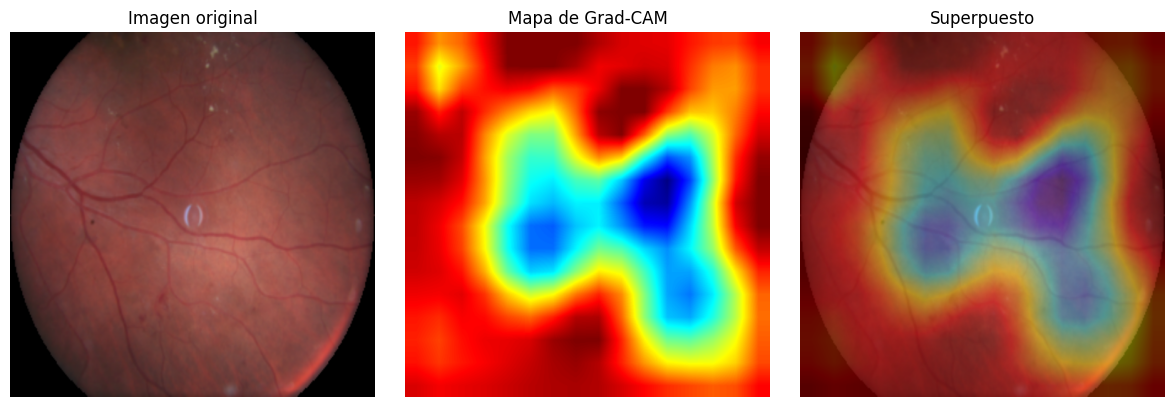

Label: 1, Predicción: 0


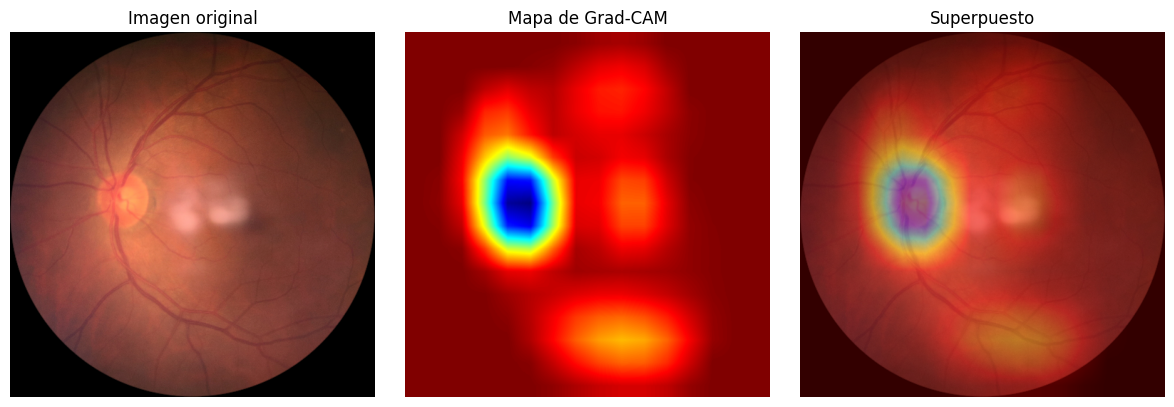

Label: 0, Predicción: 1


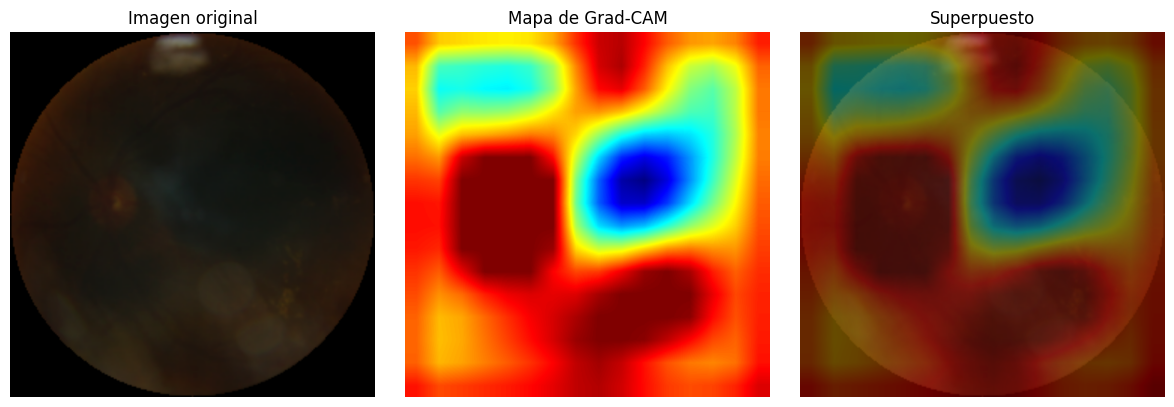

In [24]:
model = resnet18(pretrained=True)
# nro de features de salida porque la ResNet se entreno para el dataset ImageNet que tiene 1000 clases.
num_ftrs = model.fc.in_features
# creo la capa de clasificacion para la clasificaion binaria de imagenes de la retina
model.fc = nn.Linear(num_ftrs, 2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model_path = "best_baseline_layer4_fc_adam_Plateau.pth"
model.load_state_dict(torch.load(model_path,map_location=device))
model.eval()

# Diccionario para guardar activaciones y gradientes
features = {}
gradients = {}

# Hooks para capturar
def save_features(module, input, output):
    features['value'] = output.detach()

def save_gradients(module, grad_input, grad_output):
    gradients['value'] = grad_output[0].detach()

# Usamos la última capa convolucional de la ResNet18
target_layer = model.layer4[1].conv2
target_layer.register_forward_hook(save_features)
target_layer.register_backward_hook(save_gradients)

# mm = [20284]
# mb = 48314
# bm = 28127
for i in [20284, 48314, 28127]: 

    # Elegimos una imagen del validation_set
    img, label = test_set[i] # 2519
    img = img.unsqueeze(0).to(device)
    label = label.to(device)

    # Forward
    output = model(img)
    pred_class = torch.argmax(output, dim=1).item()
    print(f'Label: {label}, Predicción: {pred_class}')

    # Backward para la clase predicha
    model.zero_grad()
    score = output[0, pred_class] # selecciona el valor de salida (logit) correspondiente a la clase que fue predicha
    score.backward() # necesitamos calcular los gradientes de ese score con respecto a los mapas de activación de la última capa convolucional.
                    # ¿Qué tan sensibles son las activaciones de esa capa para cambiar el score de esta clase predicha?

    # Grad-CAM: activaciones y gradientes
    activation = features['value'][0]           # [C, H, W]
    gradient = gradients['value'][0]            # [C, H, W]

    weights = gradient.mean(dim=(1, 2))         # [C]
    cam = torch.zeros(activation.shape[1:], dtype=torch.float32).to(device)

    for i, w in enumerate(weights):
        cam += w * activation[i]

    cam = F.relu(cam)
    cam = cam - cam.min()
    cam = cam / cam.max()
    cam = cam.cpu().numpy()

    # Superposición con la imagen original
    heatmap = cv2.resize(cam, (img.shape[3], img.shape[2]))  # ancho x alto
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Convertir tensor de imagen a numpy (de-normalizado si usaste normalización)
    img_denorm = img[0].detach().cpu().clone()  # sacamos el batch, lo pasamos a CPU y lo desconectamos del grafo
    mean = torch.tensor([0.1948, 0.2880, 0.4238]).view(3, 1, 1)
    std = torch.tensor([0.1661, 0.2021, 0.2782]).view(3, 1, 1)

    # Desnormalizamos
    img_denorm = img_denorm * std + mean

    # Pasamos a [H, W, C] para visualizar
    img_np = img_denorm.permute(1, 2, 0).numpy()

    # Convertimos a 0-255 para visualizar con OpenCV
    img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)

    # Asegurar que la imagen sea del tipo correcto para cv2
    if img_np.shape[2] == 1:
        img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)

    superimposed = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

    # Mostrar resultados
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title('Imagen original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_color)
    plt.title('Mapa de Grad-CAM')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed)
    plt.title('Superpuesto')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
def evaluate_model(model_path, model, dataloaders, device):
    """
    Carga un modelo entrenado y evalúa sobre train y val.
    Retorna métricas y predicciones.
    """
    # Cargar pesos guardados
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    model.eval()

    resultados = {}

    with torch.no_grad():
        for phase in ['train', 'val']:
            all_preds = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            # Métricas
            all_preds = np.array(all_preds)
            all_labels = np.array(all_labels)

            acc = np.mean(all_preds == all_labels)
            report = classification_report(all_labels, all_preds, output_dict=True)
            cm = confusion_matrix(all_labels, all_preds)

            resultados[phase] = {
                'accuracy': acc,
                'classification_report': report,
                'confusion_matrix': cm,
                'y_true': all_labels,
                'y_pred': all_preds
            }

            print(f"--- {phase.upper()} ---")
            print("Accuracy:", acc)
            print("Classification Report:")
            print(classification_report(all_labels, all_preds))
            print("Confusion Matrix:")
            print(cm)
            print("")

    return resultados


In [ ]:
import torch
import torchvision
import cv2
import sklearn
import numpy as np
import matplotlib
import pandas as pd
import PIL
import torchcam

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("OpenCV:", cv2.__version__)
print("scikit-learn:", sklearn.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Pandas:", pd.__version__)
print("PIL:", PIL.__version__)

PyTorch: 2.5.0
Torchvision: 0.20.0
OpenCV: 4.10.0
scikit-learn: 1.5.2
NumPy: 2.0.1
Matplotlib: 3.9.2
Pandas: 2.2.3
PIL: 10.4.0


In [28]:
import platform
import psutil

print("CPU:", platform.processor())
print("RAM:", round(psutil.virtual_memory().total / (1024 ** 3)), "GB")

CPU: Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
RAM: 64 GB


## Get best val accuracy

In [53]:
import pickle

# Función para cargar el archivo y devolver el mejor accuracy de validación
def get_best_val_accuracy(pkl_file):
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    val_accuracies = data['accuracy_per_epoch']['val']
    best_acc = max(val_accuracies)
    return best_acc

# Archivos
archivo_1 = 'metrics_PLATEAU.pkl'
archivo_2 = 'metrics_Cosine.pkl'

# Obtener el mejor accuracy de validación de cada uno
best_acc_1 = get_best_val_accuracy(archivo_1)
best_acc_2 = get_best_val_accuracy(archivo_2)

# Mostrar los resultados
print(f'Mejor accuracy: {best_acc_1:.4f}')
print(f'Mejor accuracy: {best_acc_2:.4f}')


Mejor accuracy: 0.9810
Mejor accuracy: 0.9812


## Loss and Accuracy plot

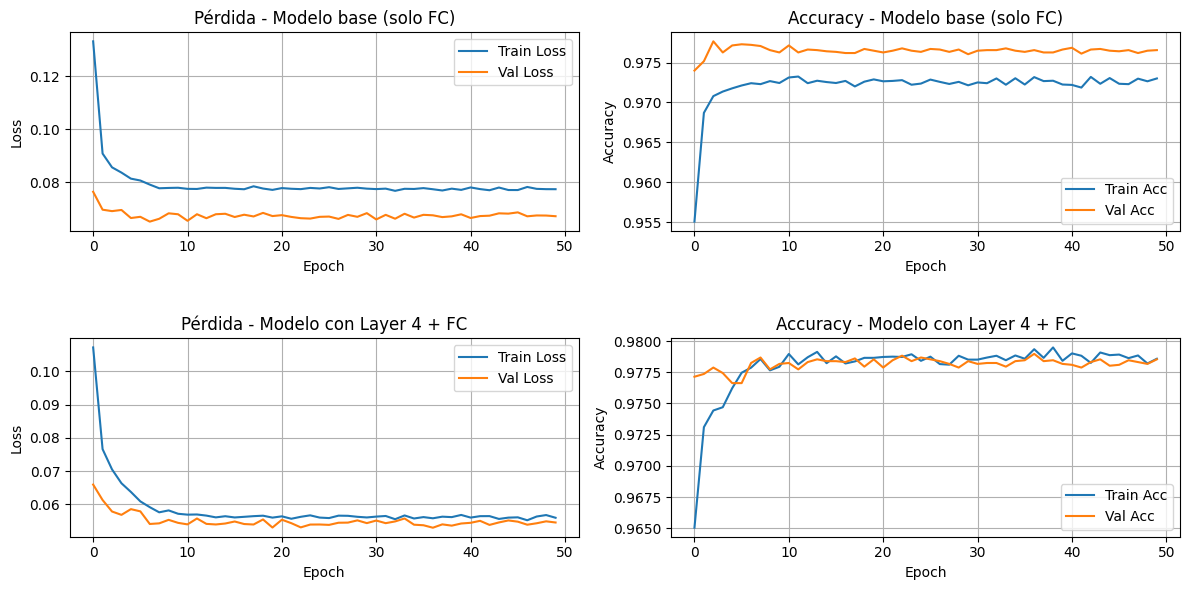

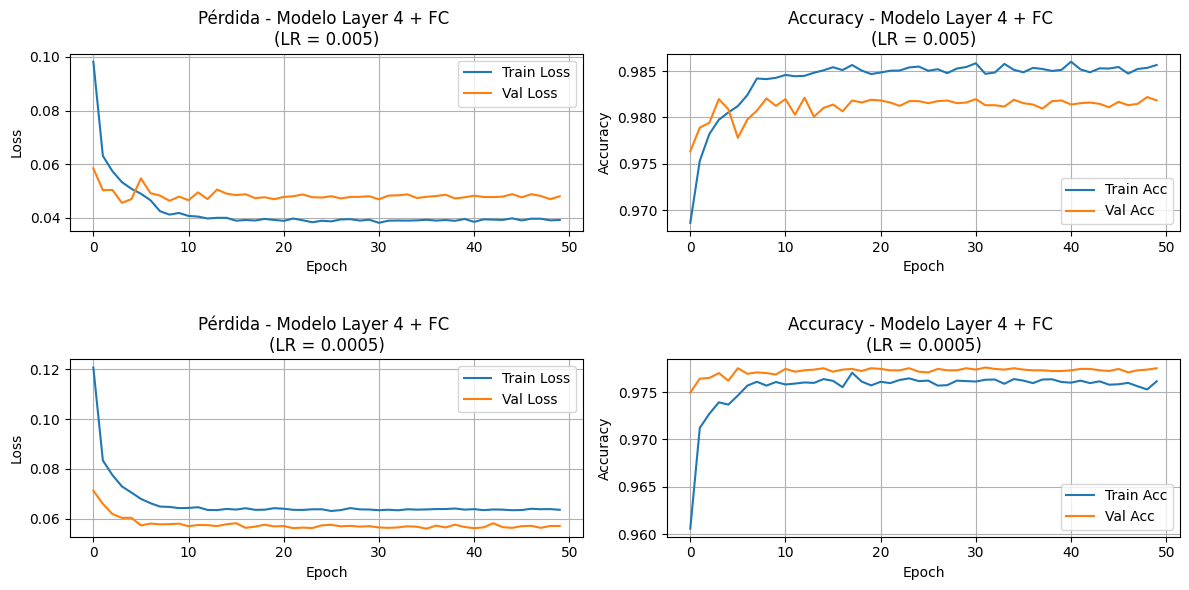

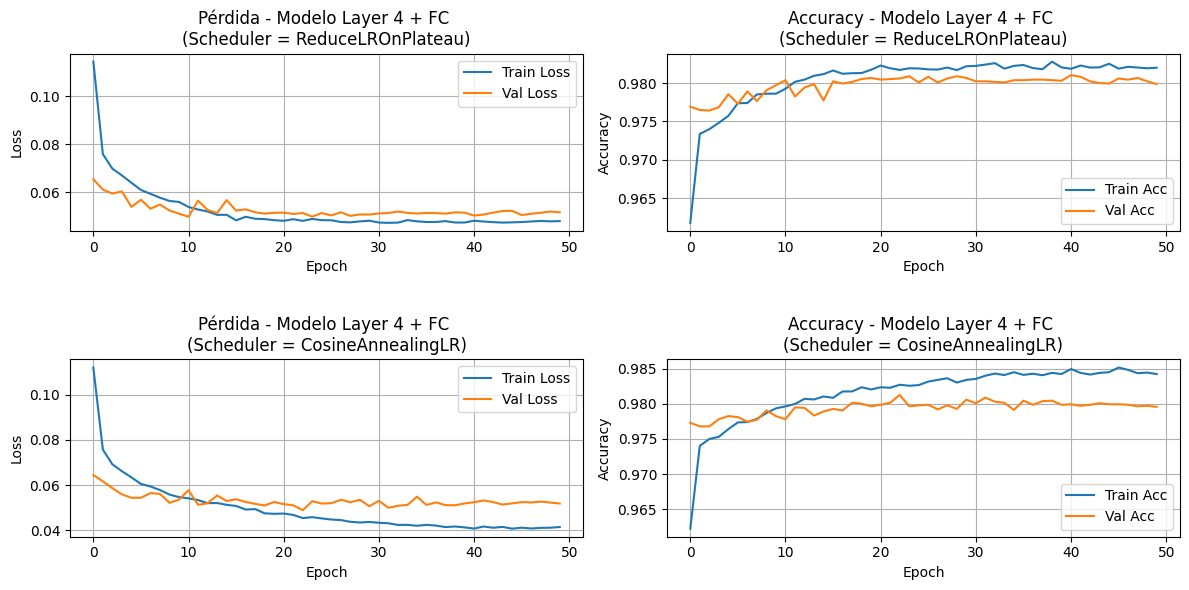

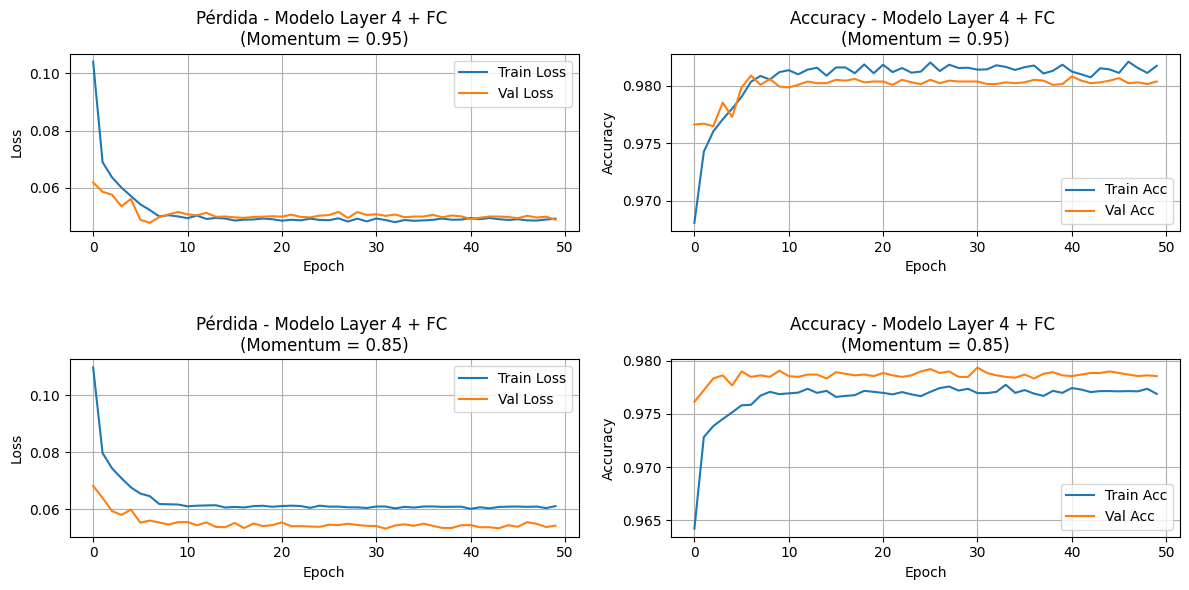

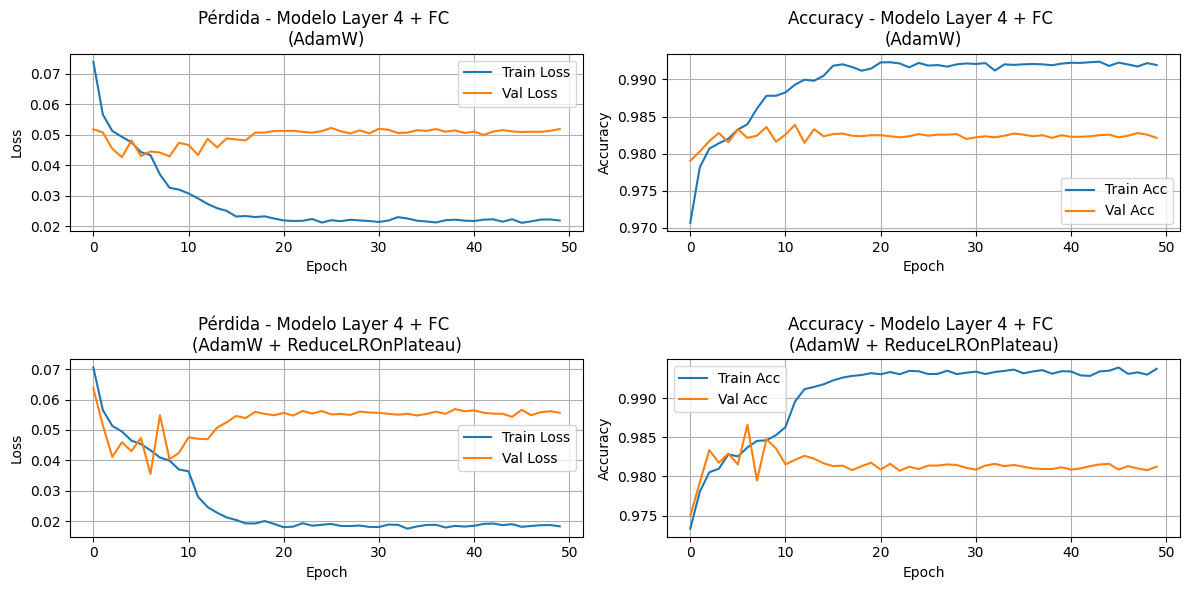

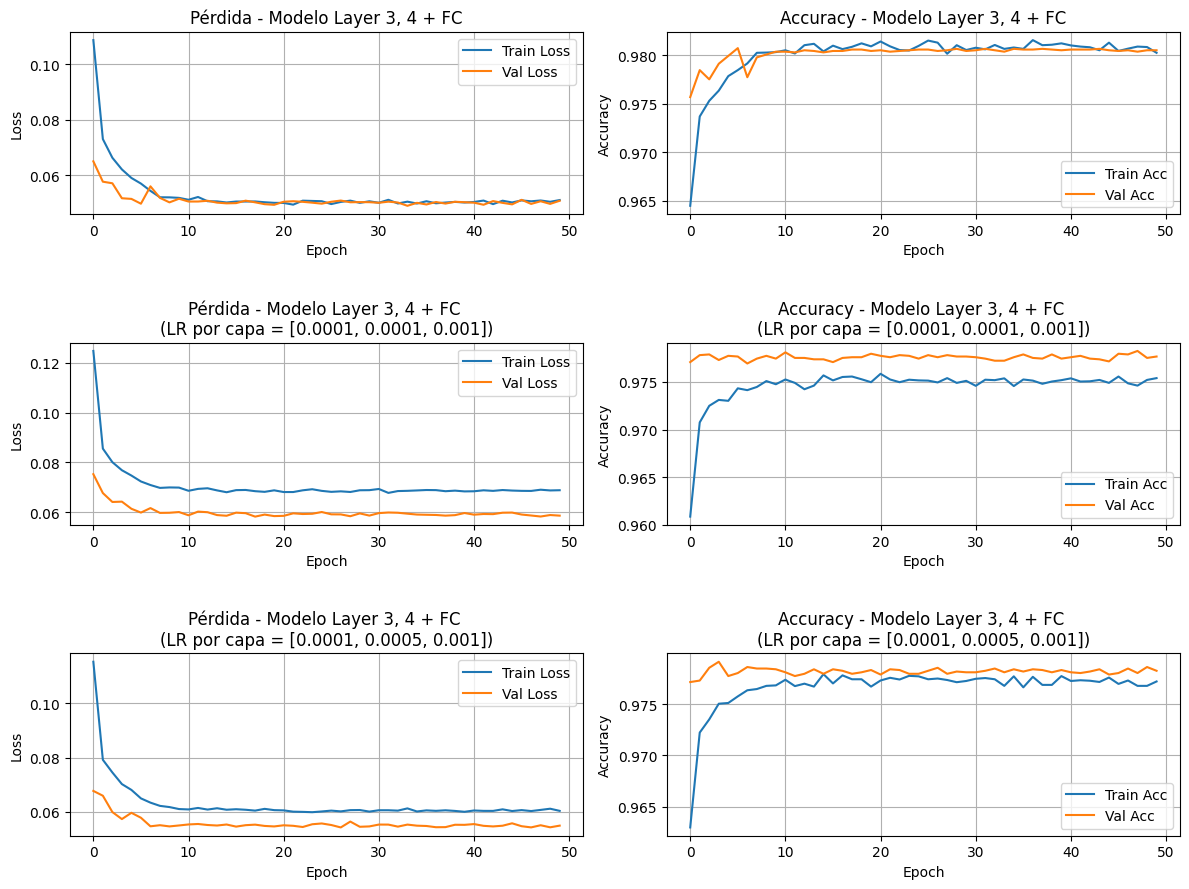

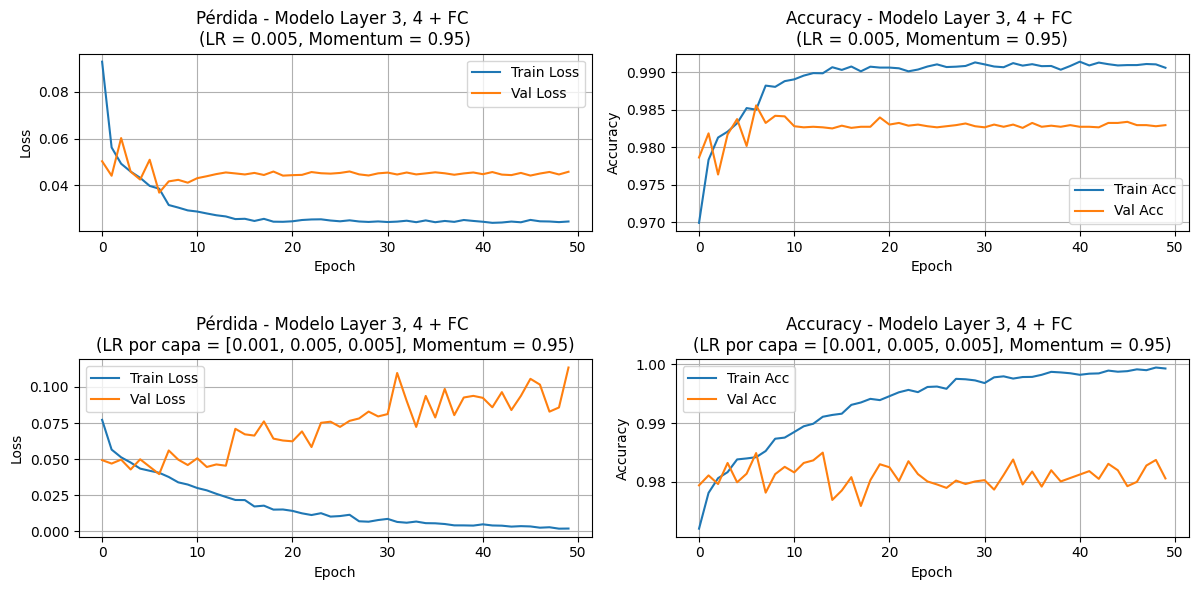

In [46]:
import matplotlib.pyplot as plt
import pickle

# Archivos y títulos
trails = ['metrics_baseline_FC.pkl', 'metrics_baseline_layer4_fc.pkl', 
          'metrics_LR005.pkl', 'metrics_LR0005.pkl', 
          'metrics_PLATEAU.pkl', 'metrics_Cosine.pkl',
          'metrics_momentum095.pkl', 'metrics_momentum085.pkl',
          'metrics_baseline_layer4_fc_adam.pkl', 'metrics_baseline_layer4_fc_adam_Plateau.pkl',
          'metrics_layer3.pkl', 'metrics_layer3_LRxcapa.pkl',
          'metrics_layer3_LRxcapa30005.pkl',
          'metrics_layer3_apuestaFuerte.pkl','metrics_version_controlada.pkl']

titles = ['Modelo base (solo FC)', 'Modelo con Layer 4 + FC',
          'Modelo Layer 4 + FC \n(LR = 0.005)', 'Modelo Layer 4 + FC \n(LR = 0.0005)',
          'Modelo Layer 4 + FC \n(Scheduler = ReduceLROnPlateau)', 'Modelo Layer 4 + FC \n(Scheduler = CosineAnnealingLR)',
          'Modelo Layer 4 + FC \n(Momentum = 0.95)', 'Modelo Layer 4 + FC \n(Momentum = 0.85)',
          'Modelo Layer 4 + FC \n(AdamW)', 'Modelo Layer 4 + FC \n(AdamW + ReduceLROnPlateau)',
          'Modelo Layer 3, 4 + FC', 'Modelo Layer 3, 4 + FC \n(LR por capa = [0.0001, 0.0001, 0.001])',
          'Modelo Layer 3, 4 + FC \n(LR por capa = [0.0001, 0.0005, 0.001])',
          'Modelo Layer 3, 4 + FC \n(LR = 0.005, Momentum = 0.95)',
          'Modelo Layer 3, 4 + FC \n(LR por capa = [0.001, 0.005, 0.005], Momentum = 0.95)'
          ]

# Parámetro para dividir en páginas de 5 modelos
chunk_size = [2,2,2,2,2,3,2]

i = 0
for c in chunk_size:
    chunk_trails = trails[i:i+c]
    chunk_titles = titles[i:i+c]
    
    fig, axes = plt.subplots(len(chunk_trails), 2, figsize=(12, 3 * len(chunk_trails)))

    for j, file in enumerate(chunk_trails):
        with open(file, 'rb') as f:
            metrics = pickle.load(f)

        train_loss = metrics['loss_per_epoch']['train']
        val_loss = metrics['loss_per_epoch']['val']
        train_acc = metrics['accuracy_per_epoch']['train']
        val_acc = metrics['accuracy_per_epoch']['val']

        # Pérdida
        axes[j, 0].plot(train_loss, label='Train Loss')
        axes[j, 0].plot(val_loss, label='Val Loss')
        axes[j, 0].set_title(f'Pérdida - {chunk_titles[j]}')
        axes[j, 0].set_xlabel('Epoch')
        axes[j, 0].set_ylabel('Loss')
        axes[j, 0].legend()
        axes[j, 0].grid(True)

        # Precisión
        axes[j, 1].plot(train_acc, label='Train Acc')
        axes[j, 1].plot(val_acc, label='Val Acc')
        axes[j, 1].set_title(f'Accuracy - {chunk_titles[j]}')
        axes[j, 1].set_xlabel('Epoch')
        axes[j, 1].set_ylabel('Accuracy')
        axes[j, 1].legend()
        axes[j, 1].grid(True)

    plt.tight_layout(h_pad=3)
    plt.show()
    i += c


## Metrics table

In [54]:
import pandas as pd
import pickle

# Cargar el archivo
with open('metrics_PLATEAU.pkl', 'rb') as f:
    metrics = pickle.load(f)

# Extraer listas
train_loss = metrics['loss_per_epoch']['train']
val_loss = metrics['loss_per_epoch']['val']
train_acc = metrics['accuracy_per_epoch']['train']
val_acc = metrics['accuracy_per_epoch']['val']

# Crear el DataFrame
df = pd.DataFrame({
    'época': list(range(1, len(train_loss) + 1)),
    'train_loss': train_loss,
    'val_loss': val_loss,
    'train_accuracy': train_acc,
    'val_accuracy': val_acc
})

df

,época,train_loss,val_loss,train_accuracy,val_accuracy
0,1,0.114430,0.065356,0.961790,0.976925
1,2,0.075830,0.060998,0.973367,0.976485
2,3,0.069760,0.059369,0.973986,0.976412
3,4,0.066956,0.060259,0.974820,0.976852
4,5,0.063868,0.053797,0.975725,0.978536
5,6,0.060875,0.056770,0.977369,0.977291
6,7,0.059259,0.053049,0.977393,0.978903
7,8,0.057630,0.054796,0.978513,0.977657
8,9,0.056297,0.052282,0.978608,0.979049
9,10,0.055870,0.050975,0.978608,0.979708
